<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/13_lstm_final_noleak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB13 — Comparação sequencial com LSTM

## 1. Papel da etapa

O NB13 avalia uma rede LSTM como experimento complementar ao núcleo tabular consolidado no NB11. A questão metodológica é verificar se a representação sequencial recorrente produz ganho suficientemente claro para substituir os escores tabulares nas etapas decisórias posteriores.

A LSTM não é tratada como evolução obrigatória do modelo tabular. Sua promoção depende de evidência temporal comparável e de um critério quantitativo previamente definido.

## 2. Referências experimentais

A etapa consome os artefatos materializados pelo NB11:

- `11_sequence_input_features.parquet`;
- `11_model_input_features.parquet`;
- `11_feature_sets.json`;
- `11_model_input_features_schema.json`;
- `11_nb11_summary.json`;
- `11_winner_model.json`, quando disponível;
- `11_baselines_summary.csv`, quando disponível.

O NB12 fornece a confirmação de governança de que `W5_K24_H12_P1_TRAIN_M2S` permanece como cenário principal e que `TRAIN_P95` continua como análise de sensibilidade.

## 3. Cenário e modelo de referência

A comparação usa como referência o vencedor do NB11:

- cenário: `W5_K24_H12_P1_TRAIN_M2S`;
- modelo tabular: Regressão Logística;
- conjunto principal: `temporal_core`;
- F1 médio no `TimeSeriesSplit`: aproximadamente 0,5773.

O valor de referência é lido dos artefatos do NB11 durante a execução, e não fixado no código como constante experimental.

## 4. Entrada sequencial

O arquivo `11_sequence_input_features.parquet` preserva a continuidade temporal necessária à construção das sequências. A elegibilidade supervisionada é aplicada apenas ao ponto final de cada sequência, evitando a formação de amostras com linhas temporalmente descontínuas.

O arquivo `11_model_input_features.parquet` é usado para rastreabilidade e conferência da matriz tabular materializada no NB11.

## 5. Contrato de atributos

Os conjuntos normativos são:

```text
raw_core: 6 atributos
temporal_core: 13 atributos
```

`raw_core` contém:

```text
fail_rate
n_events
n_failed
n_machines
n_collections
event_LOST_count
```

`temporal_core` acrescenta:

```text
lag_1
lag_2
lag_3
rolling_mean_1h
rolling_std_1h
pct_change
zscore_expanding
```

A coluna `event_FAIL_count` permanece nos dados model-facing para proveniência, mas não integra os tensores de entrada da LSTM.

## 6. Auditoria anterior ao treinamento

Antes do primeiro ajuste da rede, o notebook verifica:

- igualdade entre `n_failed` e `event_FAIL_count`;
- consistência de `fail_rate = n_failed / n_events`;
- cardinalidades 6 e 13;
- unicidade dos nomes;
- ausência de `event_FAIL_count` nos preditores;
- ausência de alvo, estado, elegibilidade, identificadores, tempo absoluto e informação futura;
- ausência de colunas exatamente duplicadas nas matrizes efetivamente usadas para formar as sequências.

Qualquer não conformidade interrompe a execução antes do treinamento.

## 7. Escopo de cenários

O modo padrão avalia:

1. o cenário principal do NB11;
2. um cenário análogo de 10 minutos, quando disponível.

O cenário de 10 minutos preserva, tanto quanto possível, o mesmo contexto histórico e o mesmo horizonte em tempo real.

## 8. Conjuntos avaliados

Para cada cenário selecionado, são avaliados:

- `raw_core`;
- `temporal_core`.

`temporal_full` pode ser carregado para rastreabilidade, mas não integra o escopo padrão, evitando ampliar desnecessariamente o custo computacional e a complexidade interpretativa.

## 9. Construção das sequências

A configuração padrão usa 24 janelas por sequência. Assim, a duração física da memória recorrente depende da granularidade:

- 120 minutos no cenário de 5 minutos;
- 240 minutos no cenário de 10 minutos.

As variáveis são ordenadas temporalmente, imputadas por propagação causal para frente e, quando necessário, completadas com zero. A padronização é ajustada somente com o trecho de treino de cada partição.

## 10. Arquitetura e repetição experimental

A configuração `FINAL_LIGHT` avalia:

- 8 e 16 unidades LSTM;
- dropout de 0,20;
- taxa de aprendizado de \(10^{-3}\);
- três sementes: 42, 123 e 2026;
- early stopping sobre a perda de validação;
- balanceamento de classes calculado no subconjunto interno de treino.

A combinação de unidades e sementes permite observar desempenho médio e variabilidade sem transformar o NB13 em busca extensa de hiperparâmetros.

## 11. Protocolos temporais

A evidência principal usa `TimeSeriesSplit` com cinco partições progressivas. O corte temporal fixo 80/20 é preservado como análise complementar e para materialização dos escores.

A validação interna para early stopping utiliza a parte final do treino de cada partição, sem embaralhamento das sequências.

## 12. Métricas

A etapa registra:

- F1;
- precisão;
- recall;
- ROC-AUC;
- Average Precision;
- Brier Score;
- matriz de confusão;
- épocas executadas;
- perda de validação;
- tempo de treinamento;
- quantidade e prevalência das amostras avaliadas.

Os valores produzidos pela saída sigmoide são interpretados como escores relativos de risco temporal.

## 13. Baselines temporais

O EWMA causal do NB11 é preservado como baseline temporal suavizado e interpretável. Ele não é usado como atributo da LSTM nem como escore principal do NB14.

A comparação central continua sendo entre a melhor LSTM e o modelo tabular vencedor do NB11. O EWMA fornece contexto adicional sobre o ganho obtido pela complexidade sequencial.

## 14. Critério de promoção

A LSTM somente pode alimentar o NB14 quando:

\[
F1_{\mathrm{LSTM,TSCV}} - F1_{\mathrm{NB11,TSCV}} \geq 0{,}03.
\]

Se o critério não for atendido, os escores do NB11 permanecem como referência, e a LSTM é registrada como análise complementar.

## 15. Artefatos esperados

O NB13 materializa:

- resultados detalhados e agregados do corte fixo;
- resultados detalhados e agregados do `TimeSeriesSplit`;
- escores da LSTM;
- plano e contrato dos atributos;
- auditoria de duplicidade;
- contexto dos baselines;
- resumo estruturado;
- conclusão textual;
- figuras diagnósticas.

A conclusão científica da etapa será redigida após a validação dos resultados e acrescentada em célula Markdown separada.


Mounted at /content/drive
[2026-07-23 20:19:15] ====================================================================================================
[2026-07-23 20:19:15] NB13 — Comparação sequencial com LSTM
[2026-07-23 20:19:15] RUN_TIMESTAMP = 2026-07-23 20:18:54
[2026-07-23 20:19:15] BASE_DIR = /content/drive/MyDrive/Mestrado
[2026-07-23 20:19:15] REPORTS_PATH = /content/drive/MyDrive/Mestrado/04-reports
[2026-07-23 20:19:15] FIGURES_PATH = /content/drive/MyDrive/Mestrado/04-reports/figures_nb13_lstm
[2026-07-23 20:19:15] ====================================================================================================
[2026-07-23 20:19:15] CONFIG:
{
  "run_mode": "FINAL_LIGHT",
  "scenario_scope": "nb11_main_plus_10min",
  "feature_sets_to_evaluate": [
    "raw_core",
    "temporal_core"
  ],
  "sequence_length": 24,
  "min_delta_f1_to_feed_nb14": 0.03,
  "classification_threshold": 0.5,
  "fixed_train_fraction": 0.8,
  "validation_fraction_from_train": 0.2,
  "save_keras_models

[2026-07-23 20:33:39] [FIM] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | feature_set=raw_core | units=8 | seed=123 | total=0.14 min | epochs=15 | best_val_loss=0.679137
[2026-07-23 20:33:41] [TREINO] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | feature_set=raw_core | units=8 | seed=2026 | X_train=(2920, 24, 6) | X_val=(584, 24, 6) | X_test=(731, 24, 6) | pos_train=421/2920


[2026-07-23 20:33:47] [FIM] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | feature_set=raw_core | units=8 | seed=2026 | total=0.10 min | epochs=12 | best_val_loss=0.693456
[2026-07-23 20:33:49] [TREINO] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | feature_set=raw_core | units=16 | seed=42 | X_train=(2920, 24, 6) | X_val=(584, 24, 6) | X_test=(731, 24, 6) | pos_train=421/2920
[2026-07-23 20:33:57] [FIM] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | feature_set=raw_core | units=16 | seed=42 | total=0.13 min | epochs=13 | best_val_loss=0.658648
[2026-07-23 20:33:58] [TREINO] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | feature_set=raw_core | units=16 | seed=123 | X_train=(2920, 24, 6) | X_val=(584, 24, 6) | X_test=(731, 24, 6) | pos_train=421/2920
[2026-07-23 20:34:04] [FIM] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | feature_set=raw_core | units=16 | seed=123 | total=0.10 min | epochs=10 | best_val_loss=0.649297
[2026-07-23 20:34:07] [TREINO] FIXED | scenario=W10_K12_H6_P1_TRAIN_M2S | feature_set=ra

,scenario_label,feature_set,protocol,units,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,...,positive_rate_mean,positive_rate_std,epochs_ran_mean,epochs_ran_std,best_val_loss_mean,best_val_loss_std,fit_elapsed_seconds_mean,fit_elapsed_seconds_std,total_elapsed_seconds_mean,total_elapsed_seconds_std
4,W5_K24_H12_P1_TRAIN_M2S,raw_core,fixed_80_20,8,0.766355,0.003294,0.783615,0.002031,0.933865,0.008479,...,0.721064,0.0,15.000000,1.000000,0.604589,0.004602,11.016170,2.319679,11.426282,2.560331
7,W5_K24_H12_P1_TRAIN_M2S,temporal_core,fixed_80_20,16,0.769231,0.001438,0.798081,0.001361,0.910269,0.003595,...,0.721064,0.0,12.333333,0.577350,0.584410,0.003662,8.486850,1.069845,8.748734,1.083831
6,W5_K24_H12_P1_TRAIN_M2S,temporal_core,fixed_80_20,8,0.769710,0.002525,0.808591,0.013318,0.892323,0.019639,...,0.721064,0.0,13.000000,1.000000,0.593581,0.005062,8.715157,0.875080,8.978244,0.881478
5,W5_K24_H12_P1_TRAIN_M2S,raw_core,fixed_80_20,16,0.753894,0.005443,0.794861,0.012439,0.888335,0.016045,...,0.721064,0.0,12.000000,1.000000,0.588395,0.002370,8.457766,1.323338,8.727271,1.322121
2,W10_K12_H6_P1_TRAIN_M2S,temporal_core,fixed_80_20,8,0.733242,0.008208,0.689372,0.014381,0.932331,0.032869,...,0.545828,0.0,13.333333,2.886751,0.665857,0.001085,6.971204,1.777880,7.215894,1.784300
3,W10_K12_H6_P1_TRAIN_M2S,temporal_core,fixed_80_20,16,0.718650,0.003443,0.675133,0.002816,0.934002,0.008802,...,0.545828,0.0,12.666667,1.154701,0.628460,0.001907,6.433683,0.262153,6.725654,0.271398
0,W10_K12_H6_P1_TRAIN_M2S,raw_core,fixed_80_20,8,0.689922,0.032411,0.646577,0.030253,0.960735,0.031337,...,0.545828,0.0,13.666667,1.527525,0.694017,0.015168,7.231841,1.377557,7.485745,1.368396
1,W10_K12_H6_P1_TRAIN_M2S,raw_core,fixed_80_20,16,0.686731,0.018807,0.650014,0.021830,0.927318,0.028904,...,0.545828,0.0,12.333333,2.081666,0.646874,0.013154,6.392502,1.001464,6.681219,0.969376


[2026-07-23 20:46:35] Resultados agregados TSCV:


,scenario_label,feature_set,protocol,units,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,...,positive_rate_mean,positive_rate_std,epochs_ran_mean,epochs_ran_std,best_val_loss_mean,best_val_loss_std,fit_elapsed_seconds_mean,fit_elapsed_seconds_std,total_elapsed_seconds_mean,total_elapsed_seconds_std
7,W5_K24_H12_P1_TRAIN_M2S,temporal_core,tscv,16,0.623469,0.128946,0.474801,0.277791,0.719978,0.263059,...,0.433477,0.237262,21.000000,12.767145,0.590021,0.063373,9.396157,4.201946,9.700609,4.185116
5,W5_K24_H12_P1_TRAIN_M2S,raw_core,tscv,16,0.625769,0.126703,0.473872,0.280477,0.686034,0.278309,...,0.433477,0.237262,22.933333,14.973628,0.581596,0.056834,10.134829,5.166708,10.414292,5.158973
6,W5_K24_H12_P1_TRAIN_M2S,temporal_core,tscv,8,0.595571,0.150460,0.471397,0.280575,0.717561,0.228867,...,0.433477,0.237262,21.533333,13.298049,0.606257,0.055157,9.448317,4.434593,9.763871,4.509620
4,W5_K24_H12_P1_TRAIN_M2S,raw_core,tscv,8,0.608053,0.126547,0.460012,0.282603,0.698699,0.283134,...,0.433477,0.237262,28.933333,15.899087,0.590572,0.052523,12.171572,5.442172,12.499955,5.434671
1,W10_K12_H6_P1_TRAIN_M2S,raw_core,tscv,16,0.609539,0.120658,0.340313,0.232992,0.684460,0.253413,...,0.265789,0.181408,18.933333,15.210272,0.594738,0.141577,7.261972,4.005146,7.554070,3.979748
0,W10_K12_H6_P1_TRAIN_M2S,raw_core,tscv,8,0.593969,0.140210,0.334318,0.222393,0.695747,0.264327,...,0.265789,0.181408,24.000000,18.458448,0.613603,0.111896,8.863011,5.108244,9.133976,5.091013
3,W10_K12_H6_P1_TRAIN_M2S,temporal_core,tscv,16,0.651535,0.137533,0.352310,0.257327,0.583666,0.335477,...,0.265789,0.181408,29.266667,18.464122,0.512370,0.185991,9.347728,4.014837,9.623219,4.003971
2,W10_K12_H6_P1_TRAIN_M2S,temporal_core,tscv,8,0.573136,0.121488,0.306371,0.269993,0.579164,0.313213,...,0.265789,0.181408,26.533333,18.558274,0.597079,0.129504,8.687699,4.140658,8.940389,4.147252


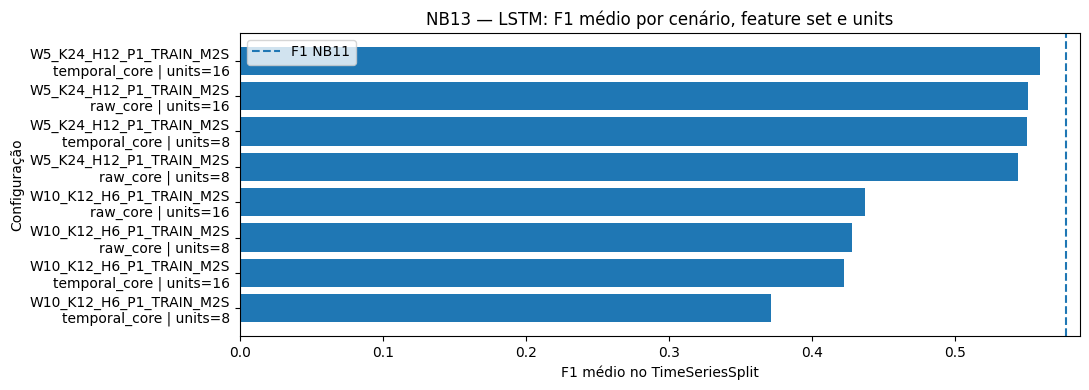

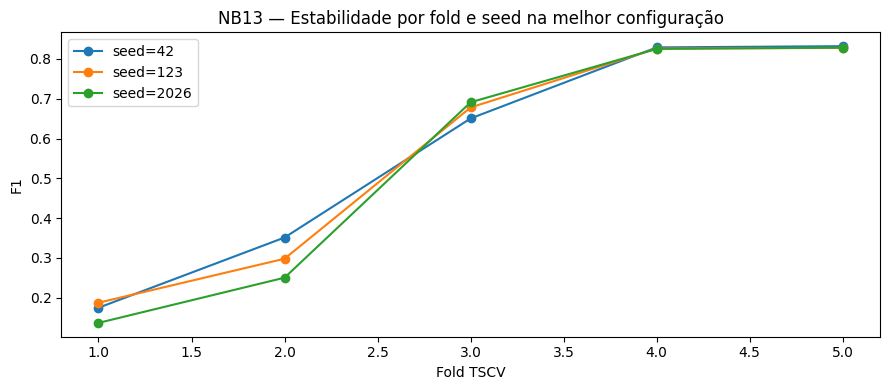

[2026-07-23 20:46:36] ====================================================================================================
[2026-07-23 20:46:36] FIM DO NB13 — Comparação sequencial com LSTM
[2026-07-23 20:46:36] Tempo total: 27.24 min
[2026-07-23 20:46:36] fixed_results: (24, 29)
[2026-07-23 20:46:36] tscv_results: (120, 29)
[2026-07-23 20:46:36] scores_df: (131484, 12)
[2026-07-23 20:46:36] Melhor F1 TSCV LSTM: 0.5590753172037944
[2026-07-23 20:46:36] Melhor F1 TSCV NB11: 0.5772970553519514
[2026-07-23 20:46:36] Delta LSTM - NB11: -0.018221738148156974
[2026-07-23 20:46:36] Decisão NB14: keep_nb11_scores_for_nb14
[2026-07-23 20:46:36] ====================================================================================================

Artefatos salvos:
- fixed_results: /content/drive/MyDrive/Mestrado/04-reports/13_lstm_fixed_results.csv
- tscv_results: /content/drive/MyDrive/Mestrado/04-reports/13_lstm_tscv_results.csv
- fixed_results_agg: /content/drive/MyDrive/Mestrado/04-reports/13

,n,n_positive,positive_rate,threshold,accuracy,precision,recall,f1,roc_auc,average_precision,...,seed,units,n_features,sequence_length,epochs_ran,best_val_loss,last_val_loss,fit_elapsed_seconds,total_elapsed_seconds,class_weight
0,1391,1003,0.721064,0.5,0.767074,0.781276,0.940179,0.853394,0.748787,0.845887,...,42,8,6,24,14,0.608987,0.629353,13.664589,14.356570,"{0: 0.6399194708081679, 1: 2.2867420349434737}"
1,1391,1003,0.721064,0.5,0.762761,0.784928,0.924227,0.848901,0.745390,0.858601,...,123,8,6,24,16,0.599808,0.612341,9.345090,9.621497,"{0: 0.6399194708081679, 1: 2.2867420349434737}"
2,1391,1003,0.721064,0.5,0.769231,0.784641,0.937188,0.854157,0.763560,0.870200,...,2026,8,6,24,15,0.604973,0.614322,10.038831,10.300779,"{0: 0.6399194708081679, 1: 2.2867420349434737}"
3,1391,1003,0.721064,0.5,0.757728,0.795737,0.893320,0.841710,0.739454,0.859283,...,42,16,6,24,12,0.588273,0.659536,9.484216,9.764776,"{0: 0.6399194708081679, 1: 2.2867420349434737}"
4,1391,1003,0.721064,0.5,0.756290,0.806839,0.870389,0.837410,0.751583,0.869909,...,123,16,6,24,11,0.586088,0.646736,6.964223,7.238626,"{0: 0.6399194708081679, 1: 2.2867420349434737}"



Amostra tscv_results:


,n,n_positive,positive_rate,threshold,accuracy,precision,recall,f1,roc_auc,average_precision,...,seed,units,n_features,sequence_length,epochs_ran,best_val_loss,last_val_loss,fit_elapsed_seconds,total_elapsed_seconds,class_weight
0,1159,240,0.207075,0.5,0.389991,0.131122,0.345833,0.190149,0.336026,0.155655,...,42,8,6,24,33,0.557114,0.566005,9.853027,10.129213,"{0: 0.5346020761245674, 1: 7.725}"
1,1159,240,0.207075,0.5,0.503020,0.131579,0.250000,0.172414,0.407671,0.167578,...,123,8,6,24,37,0.520759,0.547467,9.899869,10.282193,"{0: 0.5346020761245674, 1: 7.725}"
2,1159,240,0.207075,0.5,0.466782,0.126482,0.266667,0.171582,0.377657,0.156244,...,2026,8,6,24,48,0.576080,0.584272,12.047913,12.407082,"{0: 0.5346020761245674, 1: 7.725}"
3,1159,240,0.207075,0.5,0.435720,0.127698,0.295833,0.178392,0.340184,0.148656,...,42,16,6,24,24,0.554993,0.605843,7.464480,7.722711,"{0: 0.5346020761245674, 1: 7.725}"
4,1159,240,0.207075,0.5,0.397757,0.131833,0.341667,0.190255,0.341857,0.153248,...,123,16,6,24,25,0.509341,0.555645,8.848036,9.133145,"{0: 0.5346020761245674, 1: 7.725}"


In [1]:

# ============================================================
# NB13 — Comparação sequencial com LSTM
# Código integral da etapa
# ============================================================

import os
import re
import gc
import json
import math
import time
import shutil
import random
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
)
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 0. TensorFlow / Keras
# ------------------------------------------------------------

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    TENSORFLOW_AVAILABLE = True
except Exception as exc:
    TENSORFLOW_AVAILABLE = False
    TF_IMPORT_ERROR = repr(exc)

if not TENSORFLOW_AVAILABLE:
    raise ImportError(
        "TensorFlow/Keras não está disponível neste ambiente. "
        f"Erro original: {TF_IMPORT_ERROR}"
    )

# ------------------------------------------------------------
# 1. Log, utilidades e diretórios
# ------------------------------------------------------------

RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
RUN_TIMESTAMP_FILE = datetime.now().strftime("%Y%m%d_%H%M%S")

def now_str():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")

def log(msg):
    print(f"[{now_str()}] {msg}", flush=True)

def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def safe_load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def safe_json_dump(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2, default=str)

IN_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in globals() else False

if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as exc:
        log(f"[AVISO] Não foi possível montar o Google Drive automaticamente: {exc}")

BASE_DIR = (
    Path("/content/drive/MyDrive/Mestrado")
    if Path("/content/drive/MyDrive/Mestrado").exists()
    else Path.cwd()
)

FEATURES_PATH = ensure_dir(BASE_DIR / "02-datasets" / "03-features")
MODELS_PATH = ensure_dir(BASE_DIR / "03-models")
REPORTS_PATH = ensure_dir(BASE_DIR / "04-reports")
FIGURES_PATH = ensure_dir(REPORTS_PATH / "figures_nb13_lstm")
BACKUP_BASE_PATH = ensure_dir(REPORTS_PATH / "_backup_previous_artifacts")

log("=" * 100)
log("NB13 — Comparação sequencial com LSTM")
log(f"RUN_TIMESTAMP = {RUN_TIMESTAMP}")
log(f"BASE_DIR = {BASE_DIR}")
log(f"REPORTS_PATH = {REPORTS_PATH}")
log(f"FIGURES_PATH = {FIGURES_PATH}")
log("=" * 100)

# ------------------------------------------------------------
# 2. Configuração
# ------------------------------------------------------------

# RUN_MODE:
# - "SMOKE": teste rápido de ponta a ponta.
# - "FINAL_LIGHT": execução recomendada.
# - "FULL": execução ampliada.
RUN_MODE = "FINAL_LIGHT"

CONFIG = {
    "run_mode": RUN_MODE,

    # Escopo de cenários:
    # - "nb11_main_only": apenas o cenário vencedor do NB11.
    # - "nb11_main_plus_10min": cenário vencedor + cenário análogo de 10 min, se disponível.
    # - "all_nb11_scenarios": todos os cenários disponíveis no arquivo sequencial.
    "scenario_scope": "nb11_main_plus_10min",

    # Feature sets a avaliar.
    "feature_sets_to_evaluate": ["raw_core", "temporal_core"],

    # Sequência LSTM.
    "sequence_length": 24,

    # Critério de decisão para NB14.
    "min_delta_f1_to_feed_nb14": 0.03,
    "classification_threshold": 0.50,

    # Protocolo temporal.
    "fixed_train_fraction": 0.80,
    "validation_fraction_from_train": 0.20,

    # Controle.
    "save_keras_models": False,
    "keras_verbose": 0,
    "backup_previous_outputs": True,

    # Leitura do NB11.
    "prefer_reports_root": True,
    "allow_legacy_nb11_subdir_fallback": True,
}

if RUN_MODE == "SMOKE":
    CONFIG.update({
        "lstm_units_grid": [8],
        "seeds": [42],
        "tscv_splits": 2,
        "max_epochs": 10,
        "batch_size": 128,
        "early_stopping_patience": 3,
        "reduce_lr_patience": 2,
        "scenario_scope": "nb11_main_only",
        "feature_sets_to_evaluate": ["raw_core"],
        "keras_verbose": 1,
    })
elif RUN_MODE == "FINAL_LIGHT":
    CONFIG.update({
        "lstm_units_grid": [8, 16],
        "seeds": [42, 123, 2026],
        "tscv_splits": 5,
        "max_epochs": 50,
        "batch_size": 128,
        "early_stopping_patience": 8,
        "reduce_lr_patience": 4,
        "dropout": 0.20,
        "learning_rate": 1e-3,
    })
elif RUN_MODE == "FULL":
    CONFIG.update({
        "lstm_units_grid": [8, 16, 32],
        "seeds": [42, 123, 2026],
        "tscv_splits": 5,
        "max_epochs": 100,
        "batch_size": 128,
        "early_stopping_patience": 12,
        "reduce_lr_patience": 5,
        "dropout": 0.20,
        "learning_rate": 1e-3,
        "scenario_scope": "all_nb11_scenarios",
    })
else:
    raise ValueError(f"RUN_MODE inválido: {RUN_MODE}")

log("CONFIG:")
print(json.dumps(CONFIG, indent=2, ensure_ascii=False))

# ------------------------------------------------------------
# 3. Localização de artefatos do NB11
# ------------------------------------------------------------

def find_file(filename, required=True):
    candidates = []

    if CONFIG.get("prefer_reports_root", True):
        candidates.append(REPORTS_PATH / filename)

    if CONFIG.get("allow_legacy_nb11_subdir_fallback", True):
        candidates.append(REPORTS_PATH / "nb11" / filename)

    candidates.append(BASE_DIR / filename)

    for p in candidates:
        if Path(p).exists():
            return Path(p)

    if required:
        msg = "Arquivo obrigatório não encontrado: " + filename + "\nCandidatos:\n"
        msg += "\n".join(str(c) for c in candidates)
        raise FileNotFoundError(msg)

    return None

PATH_SEQUENCE_INPUT = find_file("11_sequence_input_features.parquet", required=True)
PATH_MODEL_INPUT = find_file("11_model_input_features.parquet", required=True)
PATH_FEATURE_SETS = find_file("11_feature_sets.json", required=True)
PATH_SCHEMA = find_file("11_model_input_features_schema.json", required=True)
PATH_NB11_SUMMARY = find_file("11_nb11_summary.json", required=True)
PATH_WINNER_MODEL = find_file("11_winner_model.json", required=False)
PATH_BASELINES_SUMMARY = find_file("11_baselines_summary.csv", required=False)
PATH_NB12_SUMMARY = find_file("12_nb12_summary.json", required=True)
PATH_NB12_REVIEW = find_file("12_train_p95_review.json", required=True)

log("Artefatos NB11 localizados:")
for name, path in {
    "sequence_input": PATH_SEQUENCE_INPUT,
    "model_input": PATH_MODEL_INPUT,
    "feature_sets": PATH_FEATURE_SETS,
    "schema": PATH_SCHEMA,
    "nb11_summary": PATH_NB11_SUMMARY,
    "winner_model": PATH_WINNER_MODEL,
    "baselines_summary": PATH_BASELINES_SUMMARY,
    "nb12_summary": PATH_NB12_SUMMARY,
    "nb12_train_p95_review": PATH_NB12_REVIEW,
}.items():
    log(f"{name}: {path}")

feature_sets_json = safe_load_json(PATH_FEATURE_SETS)
schema_json = safe_load_json(PATH_SCHEMA)
nb11_summary = safe_load_json(PATH_NB11_SUMMARY)
winner_model = safe_load_json(PATH_WINNER_MODEL) if PATH_WINNER_MODEL else nb11_summary.get("winner", {})
nb12_summary = safe_load_json(PATH_NB12_SUMMARY)
nb12_review = safe_load_json(PATH_NB12_REVIEW)

RAW_CORE = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "event_LOST_count",
]

TEMPORAL_CORE = RAW_CORE + [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_1h",
    "rolling_std_1h",
    "pct_change",
    "zscore_expanding",
]

EXPECTED_CARDINALITY = {
    "raw_core": 6,
    "temporal_core": 13,
}

assert len(RAW_CORE) == EXPECTED_CARDINALITY["raw_core"]
assert len(TEMPORAL_CORE) == EXPECTED_CARDINALITY["temporal_core"]
assert len(RAW_CORE) == len(set(RAW_CORE))
assert len(TEMPORAL_CORE) == len(set(TEMPORAL_CORE))
assert "event_FAIL_count" not in RAW_CORE
assert "event_FAIL_count" not in TEMPORAL_CORE

if feature_sets_json.get("raw_core") != RAW_CORE:
    raise AssertionError("11_feature_sets.json diverge do contrato normativo de raw_core.")

if feature_sets_json.get("temporal_core") != TEMPORAL_CORE:
    raise AssertionError("11_feature_sets.json diverge do contrato normativo de temporal_core.")

schema_sets = schema_json.get("normative_feature_sets", {})
if schema_sets.get("raw_core", {}).get("features") != RAW_CORE:
    raise AssertionError("O schema do NB11 diverge do contrato de raw_core.")

if schema_sets.get("temporal_core", {}).get("features") != TEMPORAL_CORE:
    raise AssertionError("O schema do NB11 diverge do contrato de temporal_core.")

nb12_contract = nb12_summary.get("feature_contract", {})
if nb12_contract.get("raw_core") != RAW_CORE:
    raise AssertionError("O resumo do NB12 diverge do contrato de raw_core.")

if nb12_contract.get("temporal_core") != TEMPORAL_CORE:
    raise AssertionError("O resumo do NB12 diverge do contrato de temporal_core.")

if bool(nb12_review.get("scenario_reassessment_required")):
    raise AssertionError(
        "O NB12 solicitou reavaliação do cenário principal; o NB13 não deve prosseguir automaticamente."
    )

log("Contrato de atributos e decisão de governança do NB12: PASS")

# ------------------------------------------------------------
# 3.1. Contexto dos baselines temporais do NB11, incluindo EWMA
# ------------------------------------------------------------

def _find_col(df, candidates):
    """Retorna a primeira coluna existente entre os nomes candidatos, com comparação case-insensitive."""
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    for cand in candidates:
        if cand in df.columns:
            return cand
        key = str(cand).strip().lower()
        if key in lower_map:
            return lower_map[key]
    return None

def _safe_float_value(row, col):
    """Converte valor de uma linha/dict em float, retornando None quando ausente ou inválido."""
    if row is None or col is None:
        return None
    try:
        value = row.get(col) if hasattr(row, "get") else row[col]
    except Exception:
        return None
    try:
        if pd.isna(value):
            return None
        return float(value)
    except Exception:
        return None

def _jsonable_row(row):
    """Converte linha pandas/dict em estrutura serializável em JSON."""
    if row is None:
        return None
    if hasattr(row, "to_dict"):
        row = row.to_dict()
    out = {}
    for k, v in row.items():
        try:
            if pd.isna(v):
                out[k] = None
            elif isinstance(v, (np.integer,)):
                out[k] = int(v)
            elif isinstance(v, (np.floating,)):
                out[k] = float(v)
            else:
                out[k] = v
        except Exception:
            out[k] = str(v)
    return out

def _metrics_from_row(row, cols):
    """Extrai métricas padronizadas a partir de uma linha e do mapa de colunas detectadas."""
    return {
        "f1": _safe_float_value(row, cols.get("f1")),
        "recall": _safe_float_value(row, cols.get("recall")),
        "precision": _safe_float_value(row, cols.get("precision")),
        "roc_auc": _safe_float_value(row, cols.get("roc_auc")),
        "average_precision": _safe_float_value(row, cols.get("average_precision")),
        "brier": _safe_float_value(row, cols.get("brier")),
        "false_alerts_per_day": _safe_float_value(row, cols.get("false_alerts_per_day")),
    }

def _normalize_protocol(series):
    """Normaliza rótulos de validação/protocolo para filtragem robusta."""
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .str.replace("-", "_", regex=False)
        .str.replace(" ", "_", regex=False)
    )

def _main_scenario_from_nb11(nb11_summary_dict):
    """Obtém o cenário principal do NB11, com fallback explícito."""
    fallback = "W5_K24_H12_P1_TRAIN_M2S"
    if not isinstance(nb11_summary_dict, dict):
        return fallback

    candidates = [
        nb11_summary_dict.get("scenario_label"),
        nb11_summary_dict.get("main_scenario"),
        nb11_summary_dict.get("winner_scenario"),
    ]

    for nested_key in ["winner", "winner_model", "nb11_reference", "best_model"]:
        nested = nb11_summary_dict.get(nested_key)
        if isinstance(nested, dict):
            candidates.extend([
                nested.get("scenario_label"),
                nested.get("scenario"),
                nested.get("scenario_name"),
            ])

    for value in candidates:
        if isinstance(value, str) and value.strip():
            return value.strip()

    return fallback

def extract_nb11_baseline_context(path_baselines_summary, nb11_summary_dict):
    """
    Lê o resumo de baselines do NB11 e extrai contexto comparativo para o NB13.

    Regras de extração:
    - detectar a coluna de validação entre os nomes previstos;
    - filtrar primeiro o cenário principal do NB11;
    - priorizar o EWMA no TimeSeriesSplit;
    - preservar o corte fixo 80/20 apenas como complemento;
    - não rotular como TSCV uma linha fixed_80_20 de outro cenário.
    """
    main_scenario = _main_scenario_from_nb11(nb11_summary_dict)

    context = {
        "available": False,
        "source": str(path_baselines_summary) if path_baselines_summary else None,
        "main_scenario": main_scenario,
        "preferred_protocol_for_narrative": "TimeSeriesSplit",
        "ewma_available": False,
        "ewma_main_tscv_available": False,
        "ewma_main_fixed_available": False,
        "ewma_main_tscv_row": None,
        "ewma_main_fixed_row": None,
        "ewma_main_tscv_metrics": None,
        "ewma_main_fixed_metrics": None,
        "best_baseline_main_tscv": None,
        "best_baseline_main_tscv_metrics": None,
        "best_baseline_overall_tscv": None,
        "best_baseline_overall_tscv_metrics": None,
        # Campos legados mantidos para compatibilidade com partes antigas do notebook.
        "ewma_row": None,
        "ewma_metrics": None,
        "best_baseline_tscv": None,
        "best_baseline_metrics": None,
        "notes": [
            "O EWMA é tratado como baseline comparativo herdado do NB11.",
            "O EWMA não é usado como feature da LSTM.",
            "O EWMA não substitui os escores do modelo vencedor do NB11 na cadeia NB14.",
            "A narrativa principal deve usar o EWMA do cenário principal no TimeSeriesSplit, quando disponível.",
        ],
    }

    if path_baselines_summary is None or not Path(path_baselines_summary).exists():
        context["notes"].append("Arquivo 11_baselines_summary.csv não encontrado; contexto EWMA será registrado apenas de forma descritiva.")
        return context

    try:
        dfb = pd.read_csv(path_baselines_summary)
    except Exception as exc:
        context["notes"].append(f"Falha ao ler 11_baselines_summary.csv: {exc}")
        return context

    context["available"] = True
    context["shape"] = list(dfb.shape)
    context["columns"] = list(dfb.columns)

    baseline_col = _find_col(dfb, ["baseline", "model", "model_name", "method", "name"])
    # A coluna 'validation' é o nome observado no artefato do NB11.
    protocol_col = _find_col(dfb, ["validation", "protocol", "validation_protocol", "split", "evaluation_protocol"])
    scenario_col = _find_col(dfb, ["scenario_label", "scenario", "cenario"])
    f1_col = _find_col(dfb, ["f1_mean", "f1", "mean_f1"])
    recall_col = _find_col(dfb, ["recall_mean", "recall", "mean_recall"])
    precision_col = _find_col(dfb, ["precision_mean", "precision", "mean_precision"])
    roc_auc_col = _find_col(dfb, ["roc_auc_mean", "roc_auc", "auc_mean"])
    avg_precision_col = _find_col(dfb, ["average_precision_mean", "avg_precision_mean", "average_precision", "avg_precision"])
    brier_col = _find_col(dfb, ["brier_mean", "brier", "brier_score"])
    false_alerts_col = _find_col(dfb, ["false_alerts_per_day_mean", "false_alerts_per_day"])

    cols = {
        "baseline": baseline_col,
        "protocol": protocol_col,
        "scenario": scenario_col,
        "f1": f1_col,
        "recall": recall_col,
        "precision": precision_col,
        "roc_auc": roc_auc_col,
        "average_precision": avg_precision_col,
        "brier": brier_col,
        "false_alerts_per_day": false_alerts_col,
    }
    context["detected_columns"] = cols

    required = [baseline_col, scenario_col, f1_col]
    if any(c is None for c in required):
        context["notes"].append(
            "Colunas mínimas não detectadas em 11_baselines_summary.csv; "
            "não foi possível extrair contexto EWMA com segurança."
        )
        return context

    df_work = dfb.copy()
    df_work["_baseline_norm"] = df_work[baseline_col].astype(str).str.strip().str.lower()
    df_work["_scenario_norm"] = df_work[scenario_col].astype(str).str.strip()

    if protocol_col:
        df_work["_validation_norm"] = _normalize_protocol(df_work[protocol_col])
    else:
        df_work["_validation_norm"] = "unknown"
        context["notes"].append(
            "Coluna de validação/protocolo não detectada; não é possível separar TSCV de corte fixo com segurança."
        )

    main_mask = df_work["_scenario_norm"].eq(main_scenario)
    ewma_mask = df_work["_baseline_norm"].str.contains("ewma", na=False)
    tscv_mask = df_work["_validation_norm"].str.contains("tscv|time_series|timeseries|time", regex=True, na=False)
    fixed_mask = df_work["_validation_norm"].str.contains("fixed|80_20|8020|holdout", regex=True, na=False)

    df_main = df_work.loc[main_mask].copy()
    df_main_tscv = df_work.loc[main_mask & tscv_mask].copy()
    df_overall_tscv = df_work.loc[tscv_mask].copy()

    # EWMA do cenário principal no TSCV: referência narrativa preferencial.
    ewma_main_tscv = df_work.loc[main_mask & ewma_mask & tscv_mask].copy()
    if not ewma_main_tscv.empty:
        if f1_col:
            ewma_main_tscv = ewma_main_tscv.sort_values(f1_col, ascending=False)
        row = ewma_main_tscv.iloc[0]
        context["ewma_available"] = True
        context["ewma_main_tscv_available"] = True
        context["ewma_main_tscv_row"] = _jsonable_row(row)
        context["ewma_main_tscv_metrics"] = _metrics_from_row(row, cols)
        # Campos legados apontam para a referência correta.
        context["ewma_row"] = context["ewma_main_tscv_row"]
        context["ewma_metrics"] = context["ewma_main_tscv_metrics"]
    else:
        context["notes"].append(
            f"EWMA do cenário principal {main_scenario} não encontrado no TimeSeriesSplit em 11_baselines_summary.csv."
        )

    # EWMA do cenário principal no corte fixo: apenas complementar.
    ewma_main_fixed = df_work.loc[main_mask & ewma_mask & fixed_mask].copy()
    if not ewma_main_fixed.empty:
        if f1_col:
            ewma_main_fixed = ewma_main_fixed.sort_values(f1_col, ascending=False)
        row = ewma_main_fixed.iloc[0]
        context["ewma_available"] = True
        context["ewma_main_fixed_available"] = True
        context["ewma_main_fixed_row"] = _jsonable_row(row)
        context["ewma_main_fixed_metrics"] = _metrics_from_row(row, cols)

    # Fallback: se houver EWMA no cenário principal, mas sem TSCV detectável, registra melhor linha como complementar, sem chamá-la de TSCV.
    if not context["ewma_main_tscv_available"]:
        ewma_main_any = df_work.loc[main_mask & ewma_mask].copy()
        if not ewma_main_any.empty:
            if f1_col:
                ewma_main_any = ewma_main_any.sort_values(f1_col, ascending=False)
            row = ewma_main_any.iloc[0]
            context["ewma_available"] = True
            context["ewma_main_any_row"] = _jsonable_row(row)
            context["ewma_main_any_metrics"] = _metrics_from_row(row, cols)
            context["notes"].append(
                "Há linha EWMA para o cenário principal, mas ela não foi classificada como TSCV; "
                "não usar seus valores como evidência temporal principal."
            )

    # Melhor baseline do cenário principal em TSCV.
    if f1_col and not df_main_tscv.empty:
        best_main = df_main_tscv.sort_values(f1_col, ascending=False).iloc[0]
        context["best_baseline_main_tscv"] = _jsonable_row(best_main)
        context["best_baseline_main_tscv_metrics"] = _metrics_from_row(best_main, cols)
        context["best_baseline_tscv"] = context["best_baseline_main_tscv"]
        context["best_baseline_metrics"] = {
            "name": best_main.get(baseline_col),
            **context["best_baseline_main_tscv_metrics"],
        }

    # Melhor baseline geral em TSCV, preservado para auditoria.
    if f1_col and not df_overall_tscv.empty:
        best_overall = df_overall_tscv.sort_values(f1_col, ascending=False).iloc[0]
        context["best_baseline_overall_tscv"] = _jsonable_row(best_overall)
        context["best_baseline_overall_tscv_metrics"] = _metrics_from_row(best_overall, cols)

    # Métricas consolidadas/fallback do NB12, usadas apenas se o CSV não trouxer a linha TSCV desejada.
    # Esses valores vieram da leitura consolidada do relatório NB12/NB11 e evitam repetir o erro fixed_80_20 como TSCV.
    if not context["ewma_main_tscv_available"]:
        context["ewma_main_tscv_metrics_fallback_nb12"] = {
            "f1": 0.246,
            "recall": 0.161,
            "precision": 0.786,
            "roc_auc": 0.549,
            "brier": 0.375,
        }
        context["notes"].append(
            "Fallback narrativo disponível: EWMA no TSCV do cenário principal conforme consolidação NB11/NB12 "
            "(F1=0,246; recall=0,161; precisão=0,786; ROC-AUC=0,549; Brier=0,375)."
        )

    context["interpretation"] = {
        "role": "baseline temporal suavizado herdado do NB11",
        "used_as_lstm_feature": False,
        "used_as_nb14_decision_score": False,
        "preferred_protocol_for_narrative": "TimeSeriesSplit",
        "fixed_split_role": "complementar apenas",
        "warning": (
            "Não rotular como TSCV uma linha fixed_80_20. "
            "A narrativa principal deve priorizar scenario_label=W5_K24_H12_P1_TRAIN_M2S e protocolo TimeSeriesSplit."
        ),
    }

    return context

def _format_metric(value, ndigits=4):
    if value is None:
        return "não disponível"
    try:
        if pd.isna(value):
            return "não disponível"
        return f"{float(value):.{ndigits}f}"
    except Exception:
        return str(value)

def make_ewma_conclusion_note(baseline_context, nb11_best_f1, best_lstm_f1):
    """Gera nota textual sem confundir corte fixo com TSCV."""
    parts = [
        "Contexto EWMA: o EWMA causal foi preservado como baseline temporal suavizado herdado do NB11.",
        "Ele não foi usado como feature da LSTM nem como escore decisório do NB14."
    ]

    if baseline_context.get("ewma_main_tscv_available"):
        metrics = baseline_context.get("ewma_main_tscv_metrics") or {}
        parts.append(
            "No cenário principal W5_K24_H12_P1_TRAIN_M2S, a linha EWMA do TimeSeriesSplit foi localizada em "
            "11_baselines_summary.csv. "
            f"Suas métricas são: F1={_format_metric(metrics.get('f1'))}, "
            f"recall={_format_metric(metrics.get('recall'))}, "
            f"precisão={_format_metric(metrics.get('precision'))}, "
            f"ROC-AUC={_format_metric(metrics.get('roc_auc'))} e "
            f"Brier={_format_metric(metrics.get('brier'))}."
        )
        ewma_f1 = metrics.get("f1")
    else:
        fallback = baseline_context.get("ewma_main_tscv_metrics_fallback_nb12") or {}
        if fallback:
            parts.append(
                "A linha EWMA do cenário principal no TimeSeriesSplit não foi localizada automaticamente no CSV, "
                "portanto a narrativa deve usar a referência consolidada do NB11/NB12: "
                f"F1={_format_metric(fallback.get('f1'), 3)}, "
                f"recall={_format_metric(fallback.get('recall'), 3)}, "
                f"precisão={_format_metric(fallback.get('precision'), 3)}, "
                f"ROC-AUC={_format_metric(fallback.get('roc_auc'), 3)} e "
                f"Brier={_format_metric(fallback.get('brier'), 3)}."
            )
            ewma_f1 = fallback.get("f1")
        else:
            parts.append(
                "Não foi possível localizar automaticamente as métricas TSCV do EWMA; "
                "assim, ele permanece apenas como referência comparativa descritiva."
            )
            ewma_f1 = None

    fixed_metrics = baseline_context.get("ewma_main_fixed_metrics")
    if fixed_metrics:
        parts.append(
            "O corte fixo 80/20, quando presente, deve ser tratado apenas como informação complementar "
            f"(F1={_format_metric(fixed_metrics.get('f1'))}), sem substituir a evidência TSCV."
        )

    if ewma_f1 is not None and best_lstm_f1 is not None and not np.isnan(best_lstm_f1):
        if best_lstm_f1 > ewma_f1:
            parts.append(
                "A melhor LSTM superou o EWMA em F1, mas isso só desloca o NB11 se também superar "
                "o gatilho definido contra o modelo tabular vencedor."
            )
        else:
            parts.append(
                "A melhor LSTM não superou claramente o EWMA em F1, reforçando a interpretação defensiva "
                "de que a complexidade sequencial adicional não trouxe ganho suficiente."
            )

    parts.append(
        "Qualquer valor EWMA originado de linha fixed_80_20 ou de cenário diferente do cenário principal "
        "não deve ser descrito como F1 TSCV do cenário principal."
    )

    return " ".join(parts)

nb11_baseline_context = extract_nb11_baseline_context(PATH_BASELINES_SUMMARY, nb11_summary)

baseline_context_path = REPORTS_PATH / "13_lstm_baseline_context.json"

log("Contexto dos baselines temporais do NB11:")
print(json.dumps(nb11_baseline_context, indent=2, ensure_ascii=False, default=str))

# ------------------------------------------------------------
# 4. Carregamento dos dados de entrada
# ------------------------------------------------------------

df_sequence_all = pd.read_parquet(PATH_SEQUENCE_INPUT)
df_sequence_all = df_sequence_all.loc[:, ~df_sequence_all.columns.duplicated()].copy()

# O arquivo model_input é carregado apenas para validação de existência, forma e rastreabilidade.
# A LSTM usa o sequence_input, pois ele preserva continuidade temporal.
try:
    df_model_input_ref = pd.read_parquet(PATH_MODEL_INPUT)
    model_input_shape_observed = list(df_model_input_ref.shape)
    del df_model_input_ref
    gc.collect()
except Exception as exc:
    model_input_shape_observed = None
    log(f"[AVISO] Não foi possível ler completamente 11_model_input_features.parquet: {exc}")

sequence_input_shape_observed = list(df_sequence_all.shape)

log(f"df_sequence_all.shape = {df_sequence_all.shape}")
log(f"model_input_shape_observed = {model_input_shape_observed}")

# ------------------------------------------------------------
# 5. Colunas estruturais a partir do schema
# ------------------------------------------------------------

TARGET_COL = schema_json.get("target_column", "y_nb11")
ENDPOINT_ELIGIBILITY_COL = schema_json.get("endpoint_eligibility_column", "eligible_supervised")
SCENARIO_COL = schema_json.get("scenario_column", "scenario_label")
TIME_ORDER_COL = schema_json.get("time_order_column", "bucket_id")

required_cols = [TARGET_COL, ENDPOINT_ELIGIBILITY_COL, SCENARIO_COL, TIME_ORDER_COL]

missing_required_cols = [c for c in required_cols if c not in df_sequence_all.columns]
if missing_required_cols:
    raise ValueError(
        "Colunas estruturais do schema não encontradas no sequence_input: "
        f"{missing_required_cols}"
    )

log("Colunas estruturais:")
log(f"TARGET_COL = {TARGET_COL}")
log(f"ENDPOINT_ELIGIBILITY_COL = {ENDPOINT_ELIGIBILITY_COL}")
log(f"SCENARIO_COL = {SCENARIO_COL}")
log(f"TIME_ORDER_COL = {TIME_ORDER_COL}")

# ------------------------------------------------------------
# 6. Seleção controlada de cenários
# ------------------------------------------------------------

def parse_scenario_parts(s):
    out = {}
    m = re.match(r"W(?P<W>\d+)_K(?P<K>\d+)_H(?P<H>\d+)_P(?P<P>\d+)_(?P<threshold>.+)", str(s))
    if not m:
        return out
    out = m.groupdict()
    for k in ["W", "K", "H", "P"]:
        out[k] = int(out[k])
    return out

available_scenarios = sorted(df_sequence_all[SCENARIO_COL].dropna().astype(str).unique())

nb11_winner = nb11_summary.get("winner", winner_model or {})
NB11_MAIN_SCENARIO = nb11_winner.get("scenario_label")
NB11_MAIN_F1 = nb11_winner.get("f1_tscv_mean")
NB11_MAIN_FEATURE_SET = nb11_winner.get("feature_set")
NB11_MAIN_MODEL = nb11_winner.get("model")

if NB11_MAIN_SCENARIO is None:
    raise ValueError("Não foi possível identificar o cenário vencedor do NB11.")

if NB11_MAIN_SCENARIO not in available_scenarios:
    raise ValueError(
        f"Cenário vencedor do NB11 não está no sequence_input: {NB11_MAIN_SCENARIO}"
    )

NB12_REFERENCE = nb12_summary.get("nb11_reference", {})
NB12_MAIN_SCENARIO = NB12_REFERENCE.get("scenario_label")
NB12_MAIN_FEATURE_SET = NB12_REFERENCE.get("feature_set")

if NB12_MAIN_SCENARIO != NB11_MAIN_SCENARIO:
    raise AssertionError(
        "O cenário de referência do NB12 diverge do vencedor materializado pelo NB11."
    )

if NB12_MAIN_FEATURE_SET != NB11_MAIN_FEATURE_SET:
    raise AssertionError(
        "O conjunto de atributos de referência do NB12 diverge do vencedor do NB11."
    )

if NB11_MAIN_FEATURE_SET != "temporal_core":
    raise AssertionError(
        f"O NB13 espera temporal_core como conjunto vencedor do NB11; recebido: {NB11_MAIN_FEATURE_SET}"
    )

log("Referência NB11/NB12 para o NB13: PASS")

def choose_10min_analog(main_scenario, available_scenarios):
    main_parts = parse_scenario_parts(main_scenario)

    candidates = [s for s in available_scenarios if str(s).startswith("W10_")]

    if not candidates:
        return None

    # Prioriza cenário análogo ao principal:
    # para W5 K24 H12, o análogo W10 esperado tende a ser K12 H6, mantendo janela histórica e horizonte em minutos.
    preferred = []
    if main_parts:
        expected_k = max(1, int(round(main_parts.get("K", 0) * main_parts.get("W", 5) / 10)))
        expected_h = max(1, int(round(main_parts.get("H", 0) * main_parts.get("W", 5) / 10)))
        expected_p = main_parts.get("P", 1)
        for s in candidates:
            p = parse_scenario_parts(s)
            if (
                p.get("K") == expected_k
                and p.get("H") == expected_h
                and p.get("P") == expected_p
                and "TRAIN_M2S" in str(s)
            ):
                preferred.append(s)

    if preferred:
        return sorted(preferred)[0]

    # Fallback: prioriza TRAIN_M2S, P1 e depois ordem alfabética.
    candidates = sorted(
        candidates,
        key=lambda s: (
            0 if "TRAIN_M2S" in str(s) else 1,
            0 if "_P1_" in str(s) else 1,
            str(s)
        )
    )
    return candidates[0]

def select_scenarios(config):
    scope = config["scenario_scope"]

    if scope == "nb11_main_only":
        selected = [NB11_MAIN_SCENARIO]

    elif scope == "nb11_main_plus_10min":
        selected = [NB11_MAIN_SCENARIO]
        analog = choose_10min_analog(NB11_MAIN_SCENARIO, available_scenarios)
        if analog and analog not in selected:
            selected.append(analog)

    elif scope == "all_nb11_scenarios":
        selected = available_scenarios

    else:
        raise ValueError(f"scenario_scope inválido: {scope}")

    return selected

RUN_SCENARIOS = select_scenarios(CONFIG)

log("Cenários disponíveis no sequence_input:")
print(available_scenarios)
log("Cenários selecionados para execução do NB13:")
print(RUN_SCENARIOS)

# Estimativa de carga computacional
estimated_trainings = (
    len(RUN_SCENARIOS)
    * len(CONFIG["feature_sets_to_evaluate"])
    * len(CONFIG["lstm_units_grid"])
    * len(CONFIG["seeds"])
    * (1 + CONFIG["tscv_splits"])
)

log(f"Treinamentos LSTM estimados = {estimated_trainings}")

# ------------------------------------------------------------
# 7. Seleção de atributos e prevenção de vazamento
# ------------------------------------------------------------

FORBIDDEN_EXACT = {
    "y",
    "y_nb11",
    "y_nb13",
    "target",
    "label",
    "target_col",
    TARGET_COL,
    "event_FAIL_count",

    "state",
    "operational_state",
    "estado",
    "phase",
    "episode_state",
    "is_critical",
    "is_critical_raw",
    "is_during",
    "is_before",
    "is_after",
    "is_normal",
    "horizon_complete",
    ENDPOINT_ELIGIBILITY_COL,

    "window_minutes",
    "k_before_after",
    "horizon_h",
    "k_minutes",
    "h_minutes",
    "threshold_value",
    "persistence_min_windows",
    "persistence_minutes",

    "row_position",
    "bucket_id",
    "bucket_start_us",
    "bucket_start",
    "bucket_start_dt",
    "bucket_start_datetime",
    "timestamp",
    "datetime",
    "time",
    "window_start",
    "dt",

    "scenario",
    "scenario_id",
    "scenario_label",
    "scenario_name",
    "scenario_key",
    "cenario",
}

# Padrões mais precisos.
# Não usar r"score" isolado, pois isso bloqueia indevidamente zscore_expanding.
FORBIDDEN_PATTERNS = [
    r"^y$",
    r"^y_",
    r"target",
    r"label",
    r"future",
    r"will_",
    r"ahead",
    r"state",
    r"estado",
    r"phase",
    r"during",
    r"before",
    r"after",
    r"episode",
    r"critical",
    r"normal",
    r"eligible",
    r"horizon",
    r"persistence",
    r"threshold",
    r"limiar",
    r"scenario",
    r"cenario",
    r"bucket_start",
    r"timestamp",
    r"datetime",
    r"row_position",

    # Padrões de saída de modelo, mas sem bloquear zscore_expanding.
    r"(^|_)score($|_)",
    r"(^|_)scores($|_)",
    r"(^|_)prob($|_)",
    r"(^|_)proba($|_)",
    r"(^|_)pred($|_)",
    r"(^|_)prediction($|_)",
    r"(^|_)fold($|_)",
    r"(^|_)split($|_)",
]


# Features explicitamente autorizadas pelo NB11.
# Como o NB13 lê 11_feature_sets.json, essas features são a whitelist primária.
ALLOWED_FEATURES_FROM_NB11 = set()

for key in ["raw_core", "temporal_core", "temporal_full"]:
    value = feature_sets_json.get(key)
    if isinstance(value, list):
        ALLOWED_FEATURES_FROM_NB11.update(value)

for scenario, fs_dict in feature_sets_json.get("feature_sets_by_scenario", {}).items():
    if isinstance(fs_dict, dict):
        for fs_name, fs_info in fs_dict.items():
            if isinstance(fs_info, dict):
                ALLOWED_FEATURES_FROM_NB11.update(fs_info.get("features", []))


def is_forbidden_feature(col):
    """
    Retorna True se a coluna não deve ser usada como feature.

    Regra importante:
    - features explicitamente autorizadas em 11_feature_sets.json são aceitas,
      salvo se também estiverem em FORBIDDEN_EXACT;
    - isso evita falso positivo em zscore_expanding.
    """
    c = str(col)
    lc = c.lower()

    forbidden_exact_lower = {str(x).lower() for x in FORBIDDEN_EXACT}

    if lc in forbidden_exact_lower:
        return True

    if c in ALLOWED_FEATURES_FROM_NB11:
        return False

    for pattern in FORBIDDEN_PATTERNS:
        if re.search(pattern, lc):
            return True

    return False


def get_feature_set_for_scenario(scenario_label, feature_set_name):
    by_scenario = feature_sets_json.get("feature_sets_by_scenario", {})

    if scenario_label in by_scenario and feature_set_name in by_scenario[scenario_label]:
        return list(by_scenario[scenario_label][feature_set_name].get("features", []))

    if feature_set_name in feature_sets_json and isinstance(feature_sets_json[feature_set_name], list):
        return list(feature_sets_json[feature_set_name])

    return []


def validate_feature_columns(df, feature_columns, scenario_label, feature_set_name):
    missing = [c for c in feature_columns if c not in df.columns]

    if missing:
        raise ValueError(
            f"Features ausentes no sequence_input para {scenario_label}/{feature_set_name}: {missing}"
        )

    forbidden = [c for c in feature_columns if is_forbidden_feature(c)]

    if forbidden:
        raise AssertionError(
            f"VAZAMENTO DETECTADO em {scenario_label}/{feature_set_name}: {forbidden}"
        )

    if TARGET_COL in feature_columns or ENDPOINT_ELIGIBILITY_COL in feature_columns:
        raise AssertionError(
            f"Alvo/elegibilidade entrou nas features em {scenario_label}/{feature_set_name}."
        )

    if len(feature_columns) != len(set(feature_columns)):
        raise AssertionError(
            f"Nomes repetidos em {scenario_label}/{feature_set_name}: {feature_columns}"
        )

    expected = EXPECTED_CARDINALITY.get(feature_set_name)
    if expected is not None and len(feature_columns) != expected:
        raise AssertionError(
            f"Cardinalidade inválida em {scenario_label}/{feature_set_name}: "
            f"{len(feature_columns)} != {expected}"
        )

    normative = {
        "raw_core": RAW_CORE,
        "temporal_core": TEMPORAL_CORE,
    }.get(feature_set_name)

    if normative is not None and list(feature_columns) != normative:
        raise AssertionError(
            f"Conjunto divergente do contrato em {scenario_label}/{feature_set_name}."
        )

    if "event_FAIL_count" in feature_columns:
        raise AssertionError(
            f"event_FAIL_count entrou nos preditores em {scenario_label}/{feature_set_name}."
        )

    return True


def validate_failure_provenance(df):
    required = ["n_failed", "event_FAIL_count", "n_events", "fail_rate"]
    missing = [c for c in required if c not in df.columns]

    if missing:
        raise AssertionError(
            f"Colunas necessárias à auditoria de proveniência ausentes: {missing}"
        )

    n_failed = pd.to_numeric(df["n_failed"], errors="coerce")
    event_fail = pd.to_numeric(df["event_FAIL_count"], errors="coerce")
    equal_failure_count = (
        n_failed.eq(event_fail)
        | (n_failed.isna() & event_fail.isna())
    )

    if not bool(equal_failure_count.all()):
        n_bad = int((~equal_failure_count).sum())
        raise AssertionError(
            f"Divergência entre n_failed e event_FAIL_count: {n_bad} linhas."
        )

    n_events = pd.to_numeric(df["n_events"], errors="coerce")
    fail_rate = pd.to_numeric(df["fail_rate"], errors="coerce")
    valid_denominator = n_events.gt(0) & n_failed.notna() & fail_rate.notna()

    expected_rate = n_failed.loc[valid_denominator] / n_events.loc[valid_denominator]
    observed_rate = fail_rate.loc[valid_denominator]

    if not np.allclose(
        observed_rate.to_numpy(dtype=float),
        expected_rate.to_numpy(dtype=float),
        rtol=1e-10,
        atol=1e-12,
        equal_nan=True,
    ):
        raise AssertionError("A relação fail_rate = n_failed / n_events não foi preservada.")

    return {
        "n_rows": int(len(df)),
        "n_rows_rate_checked": int(valid_denominator.sum()),
        "n_failed_event_FAIL_count_equality": True,
        "fail_rate_semantics": True,
    }


def exact_duplicate_pairs(df, feature_columns):
    pairs = []

    for i, left_name in enumerate(feature_columns):
        left = pd.to_numeric(df[left_name], errors="coerce")

        for right_name in feature_columns[i + 1:]:
            right = pd.to_numeric(df[right_name], errors="coerce")
            equal = left.eq(right) | (left.isna() & right.isna())

            if bool(equal.all()):
                pairs.append((left_name, right_name))

    return pairs


def build_model_matrix_for_audit(sequence_df, scenario_label, feature_columns):
    df = sequence_df.loc[
        sequence_df[SCENARIO_COL].astype(str) == str(scenario_label),
        feature_columns,
    ].copy()

    if df.empty:
        raise ValueError(f"Cenário sem linhas para auditoria: {scenario_label}")

    return (
        df.replace([np.inf, -np.inf], np.nan)
        .ffill()
        .fillna(0)
    )


provenance_audit = validate_failure_provenance(df_sequence_all)
log(f"Auditoria de proveniência: {provenance_audit}")

feature_plan = []

for scenario_label in RUN_SCENARIOS:
    for feature_set_name in CONFIG["feature_sets_to_evaluate"]:
        features = get_feature_set_for_scenario(scenario_label, feature_set_name)

        if not features:
            log(f"[AVISO] Feature set não disponível para {scenario_label}: {feature_set_name}")
            continue

        validate_feature_columns(df_sequence_all, features, scenario_label, feature_set_name)

        feature_plan.append({
            "scenario_label": scenario_label,
            "feature_set": feature_set_name,
            "n_features": len(features),
            "features": features,
        })

if not feature_plan:
    raise ValueError("Nenhum par cenário/feature_set válido foi selecionado.")

duplicate_audit_records = []

for item in feature_plan:
    audit_matrix = build_model_matrix_for_audit(
        df_sequence_all,
        item["scenario_label"],
        item["features"],
    )

    duplicate_pairs = exact_duplicate_pairs(audit_matrix, item["features"])

    duplicate_audit_records.append({
        "scenario_label": item["scenario_label"],
        "feature_set": item["feature_set"],
        "n_rows": int(len(audit_matrix)),
        "n_features": int(len(item["features"])),
        "duplicate_pair_count": int(len(duplicate_pairs)),
        "duplicate_pairs": json.dumps(duplicate_pairs, ensure_ascii=False),
        "event_FAIL_count_in_predictors": bool("event_FAIL_count" in item["features"]),
        "status": "PASS" if not duplicate_pairs else "FAIL",
    })

    if duplicate_pairs:
        raise AssertionError(
            f"Duplicidade exata em {item['scenario_label']}/{item['feature_set']}: "
            f"{duplicate_pairs}"
        )

duplicate_audit_df = pd.DataFrame(duplicate_audit_records)
log("Auditoria dos vetores sequenciais concluída antes do treinamento: PASS")

log("Plano de execução por cenário e feature set:")
print(pd.DataFrame([
    {
        "scenario_label": x["scenario_label"],
        "feature_set": x["feature_set"],
        "n_features": x["n_features"],
    }
    for x in feature_plan
]))

# ------------------------------------------------------------
# 8. Backup dos artefatos anteriores do NB13
# ------------------------------------------------------------

def backup_previous_outputs():
    if not CONFIG.get("backup_previous_outputs", True):
        return None

    backup_dir = ensure_dir(BACKUP_BASE_PATH / f"nb13_{RUN_TIMESTAMP_FILE}")

    patterns = [
        "13_lstm*.csv",
        "13_lstm*.json",
        "13_lstm*.parquet",
        "13_lstm*.txt",
        "13_feature_duplicate_audit.csv",
    ]

    copied = []

    for pattern in patterns:
        for p in REPORTS_PATH.glob(pattern):
            if p.is_file():
                dest = backup_dir / p.name
                shutil.copy2(p, dest)
                copied.append(str(dest))

    # Backup de figuras antigas do NB13, se existirem.
    figure_dirs = [
        REPORTS_PATH / "figures_nb13_lstm",
        REPORTS_PATH / "figures_nb13_lstm_final_noleak",
    ]

    for fig_dir in figure_dirs:
        if fig_dir.exists() and fig_dir.is_dir():
            dest_dir = backup_dir / fig_dir.name
            if dest_dir.exists():
                shutil.rmtree(dest_dir)
            shutil.copytree(fig_dir, dest_dir)
            copied.append(str(dest_dir))

    log(f"Backup de artefatos anteriores do NB13 concluído: {backup_dir}")
    log(f"Itens copiados: {len(copied)}")

    return {
        "backup_dir": str(backup_dir),
        "n_items": len(copied),
        "items": copied,
    }

backup_info = backup_previous_outputs()


def clear_previous_outputs_after_backup():
    patterns = [
        "13_lstm*.csv",
        "13_lstm*.json",
        "13_lstm*.parquet",
        "13_lstm*.txt",
        "13_feature_duplicate_audit.csv",
    ]

    removed = []

    for pattern in patterns:
        for path in REPORTS_PATH.glob(pattern):
            if path.is_file():
                path.unlink()
                removed.append(str(path))

    if FIGURES_PATH.exists():
        shutil.rmtree(FIGURES_PATH)

    ensure_dir(FIGURES_PATH)

    log(f"Artefatos anteriores removidos após backup: {len(removed)}")
    return removed


removed_previous_outputs = clear_previous_outputs_after_backup()

duplicate_audit_path = REPORTS_PATH / "13_feature_duplicate_audit.csv"
duplicate_audit_df.to_csv(duplicate_audit_path, index=False)
safe_json_dump(nb11_baseline_context, baseline_context_path)

log(f"Auditoria de atributos salva: {duplicate_audit_path}")
log(f"Contexto de baselines salvo: {baseline_context_path}")

# ------------------------------------------------------------
# 9. Preparação de sequências
# ------------------------------------------------------------

def prepare_scenario_dataframe(sequence_df, scenario_label, feature_columns):
    df = sequence_df.loc[
        sequence_df[SCENARIO_COL].astype(str) == str(scenario_label)
    ].copy()

    if df.empty:
        raise ValueError(f"Cenário sem linhas no sequence_input: {scenario_label}")

    df = df.loc[:, ~df.columns.duplicated()].copy()
    df = df.sort_values(TIME_ORDER_COL).reset_index(drop=True)

    # Preserva série contínua e usa elegibilidade apenas no endpoint.
    y = pd.to_numeric(df[TARGET_COL], errors="coerce").fillna(0).astype(int)
    endpoint_eligible = (
        pd.to_numeric(df[ENDPOINT_ELIGIBILITY_COL], errors="coerce")
        .fillna(0)
        .astype(int)
        .to_numpy()
    )

    df["y_lstm"] = y

    df[feature_columns] = (
        df[feature_columns]
        .replace([np.inf, -np.inf], np.nan)
        .ffill()
        .fillna(0)
    )

    diagnostics = {
        "scenario_label": scenario_label,
        "n_rows_full_series": int(len(df)),
        "n_endpoint_eligible_raw": int(endpoint_eligible.sum()),
        "n_positive_full_series": int(df["y_lstm"].sum()),
        "positive_rate_full_series": float(df["y_lstm"].mean()),
        "time_order_column": TIME_ORDER_COL,
        "target_column": TARGET_COL,
        "endpoint_eligibility_column": ENDPOINT_ELIGIBILITY_COL,
        "imputation_strategy": "causal_ffill_then_zero",
    }

    return df, endpoint_eligible, diagnostics

def make_sequence_end_positions(n_rows, sequence_length, endpoint_eligible):
    base = np.arange(sequence_length - 1, n_rows, dtype=int)
    return base[endpoint_eligible[base].astype(bool)]

def build_X_y_from_scaled_values(values_scaled, y, end_positions, sequence_length):
    X = np.empty(
        (len(end_positions), sequence_length, values_scaled.shape[1]),
        dtype=np.float32
    )
    y_out = np.empty(len(end_positions), dtype=np.int32)

    for j, end in enumerate(end_positions):
        start = end - sequence_length + 1
        X[j] = values_scaled[start:end + 1, :]
        y_out[j] = y[end]

    return X, y_out

def scale_and_build_sequences_for_split(
    df,
    feature_columns,
    end_positions,
    train_seq_idx,
    test_seq_idx,
    sequence_length
):
    raw_values = df[feature_columns].to_numpy(dtype=np.float32)
    y_raw = df["y_lstm"].to_numpy(dtype=np.int32)

    train_end_positions = end_positions[train_seq_idx]
    test_end_positions = end_positions[test_seq_idx]

    max_train_end_row = int(train_end_positions.max())

    scaler = StandardScaler()
    scaler.fit(raw_values[:max_train_end_row + 1, :])

    values_scaled = scaler.transform(raw_values).astype(np.float32)

    X_train, y_train = build_X_y_from_scaled_values(
        values_scaled,
        y_raw,
        train_end_positions,
        sequence_length
    )

    X_test, y_test = build_X_y_from_scaled_values(
        values_scaled,
        y_raw,
        test_end_positions,
        sequence_length
    )

    expected_dim = len(feature_columns)

    if X_train.ndim != 3 or X_test.ndim != 3:
        raise AssertionError("Os tensores da LSTM devem possuir três dimensões.")

    if X_train.shape[2] != expected_dim or X_test.shape[2] != expected_dim:
        raise AssertionError(
            f"Dimensão de atributos incompatível: esperado={expected_dim}, "
            f"treino={X_train.shape[2]}, teste={X_test.shape[2]}."
        )

    return X_train, y_train, X_test, y_test, scaler

# ------------------------------------------------------------
# 10. Modelo, treinamento e métricas
# ------------------------------------------------------------

def set_all_seeds(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def chronological_train_val_split(train_indices, validation_fraction):
    train_indices = np.array(train_indices, dtype=int)

    if len(train_indices) < 10:
        return train_indices, train_indices

    val_size = max(1, int(math.ceil(len(train_indices) * validation_fraction)))

    if val_size >= len(train_indices):
        val_size = max(1, len(train_indices) // 5)

    inner_train = train_indices[:-val_size]
    inner_val = train_indices[-val_size:]

    if len(inner_train) == 0:
        return train_indices, train_indices

    return inner_train, inner_val

def compute_safe_class_weight(y_train):
    if len(np.unique(y_train)) < 2:
        return None

    weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=y_train.astype(int),
    )

    return {0: float(weights[0]), 1: float(weights[1])}

def build_lstm_model(input_shape, units=8, dropout=0.2, learning_rate=1e-3):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(units, return_sequences=False),
        layers.Dropout(dropout),
        layers.Dense(1, activation="sigmoid"),
    ])

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc"),
            keras.metrics.AUC(name="average_precision", curve="PR"),
        ],
    )

    return model

def safe_auc(metric_func, y_true, y_score):
    try:
        if len(np.unique(y_true)) < 2:
            return np.nan
        return float(metric_func(y_true, y_score))
    except Exception:
        return np.nan

def binary_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "n": int(len(y_true)),
        "n_positive": int(y_true.sum()),
        "positive_rate": float(y_true.mean()) if len(y_true) else np.nan,
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": safe_auc(roc_auc_score, y_true, y_score),
        "average_precision": safe_auc(average_precision_score, y_true, y_score),
        "brier": float(brier_score_loss(y_true, y_score)) if len(np.unique(y_true)) > 1 else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

def fit_predict_lstm(X_train, y_train, X_test, seed, units, config, run_label=""):
    set_all_seeds(seed)

    train_idx_all = np.arange(len(X_train))

    inner_train_idx, inner_val_idx = chronological_train_val_split(
        train_idx_all,
        config["validation_fraction_from_train"]
    )

    X_inner_train = X_train[inner_train_idx]
    y_inner_train = y_train[inner_train_idx]
    X_val = X_train[inner_val_idx]
    y_val = y_train[inner_val_idx]

    log(
        f"[TREINO] {run_label} | X_train={X_train.shape} | "
        f"X_val={X_val.shape} | X_test={X_test.shape} | "
        f"pos_train={int(y_train.sum())}/{len(y_train)}"
    )

    model = build_lstm_model(
        input_shape=X_train.shape[1:],
        units=units,
        dropout=config["dropout"],
        learning_rate=config["learning_rate"],
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=config["early_stopping_patience"],
            restore_best_weights=True,
            verbose=0,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=config["reduce_lr_patience"],
            min_lr=1e-6,
            verbose=0,
        ),
    ]

    class_weight = compute_safe_class_weight(y_inner_train)

    t0 = time.time()

    history = model.fit(
        X_inner_train,
        y_inner_train,
        validation_data=(X_val, y_val),
        epochs=config["max_epochs"],
        batch_size=config["batch_size"],
        verbose=config.get("keras_verbose", 0),
        callbacks=callbacks,
        class_weight=class_weight,
        shuffle=False,
    )

    fit_elapsed = time.time() - t0

    y_score = model.predict(
        X_test,
        batch_size=config["batch_size"],
        verbose=0
    ).reshape(-1)

    total_elapsed = time.time() - t0

    fit_info = {
        "epochs_ran": int(len(history.history.get("loss", []))),
        "best_val_loss": float(np.nanmin(history.history.get("val_loss", [np.nan]))),
        "last_val_loss": float(history.history.get("val_loss", [np.nan])[-1]),
        "fit_elapsed_seconds": float(fit_elapsed),
        "total_elapsed_seconds": float(total_elapsed),
        "class_weight": class_weight,
    }

    log(
        f"[FIM] {run_label} | total={total_elapsed/60:.2f} min | "
        f"epochs={fit_info['epochs_ran']} | best_val_loss={fit_info['best_val_loss']:.6f}"
    )

    return y_score, fit_info, model

# ------------------------------------------------------------
# 11. Avaliação fixed split e TSCV
# ------------------------------------------------------------

def evaluate_fixed_split(df, feature_columns, endpoint_eligible, scenario_label, feature_set_name, config):
    sequence_length = config["sequence_length"]
    end_positions = make_sequence_end_positions(len(df), sequence_length, endpoint_eligible)

    if len(end_positions) < 50:
        raise ValueError(
            f"Poucas sequências elegíveis para {scenario_label}/{feature_set_name}: {len(end_positions)}"
        )

    n_seq = len(end_positions)
    split_at = int(math.floor(n_seq * config["fixed_train_fraction"]))

    train_seq_idx = np.arange(0, split_at)
    test_seq_idx = np.arange(split_at, n_seq)

    log(
        f"[FIXED SETUP] {scenario_label}/{feature_set_name} | n_seq={n_seq} | "
        f"treino_seq={len(train_seq_idx)} | teste_seq={len(test_seq_idx)}"
    )

    X_train, y_train, X_test, y_test, scaler = scale_and_build_sequences_for_split(
        df,
        feature_columns,
        end_positions,
        train_seq_idx,
        test_seq_idx,
        sequence_length
    )

    rows = []
    score_rows = []

    for units in config["lstm_units_grid"]:
        for seed in config["seeds"]:
            run_label = (
                f"FIXED | scenario={scenario_label} | feature_set={feature_set_name} | "
                f"units={units} | seed={seed}"
            )

            y_score, fit_info, model = fit_predict_lstm(
                X_train,
                y_train,
                X_test,
                seed,
                units,
                config,
                run_label=run_label
            )

            m = binary_metrics(
                y_test,
                y_score,
                threshold=config["classification_threshold"]
            )

            m.update({
                "scenario_label": scenario_label,
                "feature_set": feature_set_name,
                "protocol": "fixed_80_20",
                "fold": 0,
                "seed": seed,
                "units": units,
                "n_features": len(feature_columns),
                "sequence_length": sequence_length,
                **fit_info,
            })

            rows.append(m)

            tmp = pd.DataFrame({
                "scenario_label": scenario_label,
                "feature_set": feature_set_name,
                "protocol": "fixed_80_20",
                "fold": 0,
                "seed": seed,
                "units": units,
                "seq_index": test_seq_idx,
                "row_end_position": end_positions[test_seq_idx],
                "time_order": df.iloc[end_positions[test_seq_idx]][TIME_ORDER_COL].to_numpy(),
                "y_true": y_test,
                "score_lstm": y_score,
                "y_pred_050": (y_score >= config["classification_threshold"]).astype(int),
            })

            score_rows.append(tmp)

            if config.get("save_keras_models", False):
                model_dir = ensure_dir(MODELS_PATH / "nb13_lstm")
                model.save(
                    model_dir / f"13_lstm_{scenario_label}_{feature_set_name}_fixed_units{units}_seed{seed}.keras"
                )

            del model
            keras.backend.clear_session()
            gc.collect()

    return pd.DataFrame(rows), pd.concat(score_rows, ignore_index=True)

def evaluate_tscv(df, feature_columns, endpoint_eligible, scenario_label, feature_set_name, config):
    sequence_length = config["sequence_length"]
    end_positions = make_sequence_end_positions(len(df), sequence_length, endpoint_eligible)

    if len(end_positions) < 100:
        raise ValueError(
            f"Poucas sequências elegíveis para TSCV em {scenario_label}/{feature_set_name}: {len(end_positions)}"
        )

    n_seq = len(end_positions)
    tscv = TimeSeriesSplit(n_splits=config["tscv_splits"])

    rows = []
    score_rows = []

    log(
        f"[TSCV SETUP] {scenario_label}/{feature_set_name} | n_seq={n_seq} | "
        f"splits={config['tscv_splits']}"
    )

    for fold, (train_seq_idx, test_seq_idx) in enumerate(tscv.split(np.arange(n_seq)), start=1):
        log(
            f"[TSCV FOLD] {scenario_label}/{feature_set_name} | fold={fold} | "
            f"treino_seq={len(train_seq_idx)} | teste_seq={len(test_seq_idx)}"
        )

        X_train, y_train, X_test, y_test, scaler = scale_and_build_sequences_for_split(
            df,
            feature_columns,
            end_positions,
            train_seq_idx,
            test_seq_idx,
            sequence_length
        )

        if len(np.unique(y_train)) < 2:
            log(f"[AVISO] Fold {fold} ignorado: treino contém uma única classe.")
            continue

        for units in config["lstm_units_grid"]:
            for seed in config["seeds"]:
                run_label = (
                    f"TSCV | scenario={scenario_label} | feature_set={feature_set_name} | "
                    f"fold={fold} | units={units} | seed={seed}"
                )

                y_score, fit_info, model = fit_predict_lstm(
                    X_train,
                    y_train,
                    X_test,
                    seed,
                    units,
                    config,
                    run_label=run_label
                )

                m = binary_metrics(
                    y_test,
                    y_score,
                    threshold=config["classification_threshold"]
                )

                m.update({
                    "scenario_label": scenario_label,
                    "feature_set": feature_set_name,
                    "protocol": "tscv",
                    "fold": fold,
                    "seed": seed,
                    "units": units,
                    "n_features": len(feature_columns),
                    "sequence_length": sequence_length,
                    **fit_info,
                })

                rows.append(m)

                tmp = pd.DataFrame({
                    "scenario_label": scenario_label,
                    "feature_set": feature_set_name,
                    "protocol": "tscv",
                    "fold": fold,
                    "seed": seed,
                    "units": units,
                    "seq_index": test_seq_idx,
                    "row_end_position": end_positions[test_seq_idx],
                    "time_order": df.iloc[end_positions[test_seq_idx]][TIME_ORDER_COL].to_numpy(),
                    "y_true": y_test,
                    "score_lstm": y_score,
                    "y_pred_050": (y_score >= config["classification_threshold"]).astype(int),
                })

                score_rows.append(tmp)

                if config.get("save_keras_models", False):
                    model_dir = ensure_dir(MODELS_PATH / "nb13_lstm")
                    model.save(
                        model_dir / f"13_lstm_{scenario_label}_{feature_set_name}_tscv{fold}_units{units}_seed{seed}.keras"
                    )

                del model
                keras.backend.clear_session()
                gc.collect()

    scores = pd.concat(score_rows, ignore_index=True) if score_rows else pd.DataFrame()
    return pd.DataFrame(rows), scores

def aggregate_results(df):
    if df.empty:
        return df

    group_cols = ["scenario_label", "feature_set", "protocol", "units"]

    metric_cols = [
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc",
        "average_precision",
        "brier",
        "n",
        "n_positive",
        "positive_rate",
        "epochs_ran",
        "best_val_loss",
        "fit_elapsed_seconds",
        "total_elapsed_seconds",
    ]

    existing_metric_cols = [c for c in metric_cols if c in df.columns]

    agg = df.groupby(group_cols)[existing_metric_cols].agg(["mean", "std"]).reset_index()

    agg.columns = [
        "_".join([x for x in col if x]) if isinstance(col, tuple) else col
        for col in agg.columns
    ]

    return agg

# ------------------------------------------------------------
# 12. Execução principal
# ------------------------------------------------------------

all_fixed_results = []
all_tscv_results = []
all_scores = []
all_diagnostics = []

global_t0 = time.time()

for item in feature_plan:
    scenario_label = item["scenario_label"]
    feature_set_name = item["feature_set"]
    feature_columns = item["features"]

    item_t0 = time.time()

    log("\n" + "=" * 100)
    log(f"NB13 LSTM | cenário={scenario_label} | feature_set={feature_set_name}")
    log("=" * 100)

    df_s, endpoint_eligible, diag = prepare_scenario_dataframe(
        df_sequence_all,
        scenario_label,
        feature_columns
    )

    end_positions_count = len(make_sequence_end_positions(
        len(df_s),
        CONFIG["sequence_length"],
        endpoint_eligible
    ))

    diag.update({
        "feature_set": feature_set_name,
        "n_features": len(feature_columns),
        "features": feature_columns,
        "n_sequence_endpoints": int(end_positions_count),
    })

    all_diagnostics.append(diag)

    log(f"Linhas série completa: {diag['n_rows_full_series']}")
    log(f"Endpoints elegíveis brutos: {diag['n_endpoint_eligible_raw']}")
    log(f"Endpoints após sequence_length: {diag['n_sequence_endpoints']}")
    log(f"Features: {feature_columns}")

    fixed_t0 = time.time()
    fixed_df, fixed_scores = evaluate_fixed_split(
        df_s,
        feature_columns,
        endpoint_eligible,
        scenario_label,
        feature_set_name,
        CONFIG
    )
    log(f"[FIXED] Concluído em {(time.time() - fixed_t0)/60:.2f} min")

    tscv_t0 = time.time()
    tscv_df, tscv_scores = evaluate_tscv(
        df_s,
        feature_columns,
        endpoint_eligible,
        scenario_label,
        feature_set_name,
        CONFIG
    )
    log(f"[TSCV] Concluído em {(time.time() - tscv_t0)/60:.2f} min")

    all_fixed_results.append(fixed_df)
    all_tscv_results.append(tscv_df)
    all_scores.append(fixed_scores)
    all_scores.append(tscv_scores)

    log(f"[FIM ITEM] {scenario_label}/{feature_set_name} | tempo={(time.time() - item_t0)/60:.2f} min")

fixed_results = pd.concat(all_fixed_results, ignore_index=True) if all_fixed_results else pd.DataFrame()
tscv_results = pd.concat(all_tscv_results, ignore_index=True) if all_tscv_results else pd.DataFrame()
scores_df = pd.concat(all_scores, ignore_index=True) if all_scores else pd.DataFrame()

fixed_agg = aggregate_results(fixed_results)
tscv_agg = aggregate_results(tscv_results)

log("Resultados agregados FIXED:")
display(fixed_agg.sort_values("f1_mean", ascending=False).head(20))

log("Resultados agregados TSCV:")
display(tscv_agg.sort_values("f1_mean", ascending=False).head(20))

# ------------------------------------------------------------
# 13. Melhor configuração e decisão para NB14
# ------------------------------------------------------------

if not tscv_agg.empty:
    best_lstm_row = (
        tscv_agg
        .sort_values(
            ["f1_mean", "recall_mean", "average_precision_mean"],
            ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )
else:
    best_lstm_row = {}

best_lstm_f1 = (
    float(best_lstm_row.get("f1_mean", np.nan))
    if best_lstm_row
    else np.nan
)

nb11_best_f1 = float(NB11_MAIN_F1) if NB11_MAIN_F1 is not None else None

if nb11_best_f1 is None or np.isnan(best_lstm_f1):
    delta_vs_nb11 = None
    feed_nb14_decision = "pending_nb11_reference"
else:
    delta_vs_nb11 = best_lstm_f1 - nb11_best_f1
    feed_nb14_decision = (
        "lstm_scores_can_feed_nb14"
        if delta_vs_nb11 >= CONFIG["min_delta_f1_to_feed_nb14"]
        else "keep_nb11_scores_for_nb14"
    )

# ------------------------------------------------------------
# 14. Salvamento dos artefatos primários
# ------------------------------------------------------------

fixed_results_path = REPORTS_PATH / "13_lstm_fixed_results.csv"
tscv_results_path = REPORTS_PATH / "13_lstm_tscv_results.csv"
fixed_agg_path = REPORTS_PATH / "13_lstm_fixed_results_agg.csv"
tscv_agg_path = REPORTS_PATH / "13_lstm_tscv_results_agg.csv"
scores_path = REPORTS_PATH / "13_lstm_scores.parquet"
summary_path = REPORTS_PATH / "13_lstm_summary.json"
feature_columns_path = REPORTS_PATH / "13_lstm_feature_columns.json"
baseline_context_path = REPORTS_PATH / "13_lstm_baseline_context.json"
conclusion_path = REPORTS_PATH / "13_lstm_conclusion.txt"

fixed_results.to_csv(fixed_results_path, index=False)
tscv_results.to_csv(tscv_results_path, index=False)
fixed_agg.to_csv(fixed_agg_path, index=False)
tscv_agg.to_csv(tscv_agg_path, index=False)

try:
    scores_df.to_parquet(scores_path, index=False)
except Exception as exc:
    scores_path = REPORTS_PATH / "13_lstm_scores.csv"
    scores_df.to_csv(scores_path, index=False)
    log(f"[AVISO] Falha ao salvar parquet. Scores salvos em CSV: {exc}")

feature_columns_info = {
    "created_at": RUN_TIMESTAMP,
    "source": "11_feature_sets.json",
    "sequence_input_path": str(PATH_SEQUENCE_INPUT),
    "model_input_path": str(PATH_MODEL_INPUT),
    "schema_path": str(PATH_SCHEMA),
    "scenario_scope": CONFIG["scenario_scope"],
    "feature_sets_to_evaluate": CONFIG["feature_sets_to_evaluate"],
    "feature_plan": feature_plan,
    "leakage_control": {
        "target_column": TARGET_COL,
        "endpoint_eligibility_column": ENDPOINT_ELIGIBILITY_COL,
        "scenario_column": SCENARIO_COL,
        "time_order_column": TIME_ORDER_COL,
        "forbidden_exact": sorted(list(FORBIDDEN_EXACT)),
        "forbidden_patterns": FORBIDDEN_PATTERNS,
        "statement": (
            "A LSTM usa somente features whitelisted em 11_feature_sets.json. "
            "Alvo, elegibilidade, estados, criticidade, horizonte, cenário, tempo absoluto, "
            "scores e predições são proibidos como features."
        ),
    },
}

safe_json_dump(feature_columns_info, feature_columns_path)

declared_outputs = {
    "fixed_results": str(fixed_results_path),
    "tscv_results": str(tscv_results_path),
    "fixed_results_agg": str(fixed_agg_path),
    "tscv_results_agg": str(tscv_agg_path),
    "scores": str(scores_path),
    "summary": str(summary_path),
    "feature_columns": str(feature_columns_path),
    "baseline_context": str(baseline_context_path),
    "conclusion": str(conclusion_path),
    "feature_duplicate_audit": str(duplicate_audit_path),
}

missing_outputs = {
    k: v for k, v in declared_outputs.items()
    if not Path(v).exists()
}

summary = {
    "notebook": "NB13",
    "title": "Comparação sequencial com LSTM",
    "executed_at": RUN_TIMESTAMP,
    "objective": (
        "Avaliar LSTM como experimento complementar usando os artefatos materializados "
        "pelo NB11 e os mesmos conjuntos de features, especialmente raw_core e temporal_core."
    ),
    "config": CONFIG,
    "run_scenarios": RUN_SCENARIOS,
    "feature_sets_evaluated": CONFIG["feature_sets_to_evaluate"],
    "estimated_trainings": int(estimated_trainings),
    "actual_trainings_fixed": int(len(fixed_results)),
    "actual_trainings_tscv": int(len(tscv_results)),
    "nb11_reference": {
        "scenario_label": NB11_MAIN_SCENARIO,
        "model": NB11_MAIN_MODEL,
        "feature_set": NB11_MAIN_FEATURE_SET,
        "f1_tscv_mean": nb11_best_f1,
    },
    "best_lstm_tscv": best_lstm_row,
    "best_lstm_f1_tscv_mean": best_lstm_f1,
    "delta_f1_lstm_minus_nb11": delta_vs_nb11,
    "min_delta_f1_to_feed_nb14": CONFIG["min_delta_f1_to_feed_nb14"],
    "feed_nb14_decision": feed_nb14_decision,
    "diagnostics": all_diagnostics,
    "input_artifacts": {
        "sequence_input_features": str(PATH_SEQUENCE_INPUT),
        "model_input_features": str(PATH_MODEL_INPUT),
        "feature_sets": str(PATH_FEATURE_SETS),
        "model_input_features_schema": str(PATH_SCHEMA),
        "nb11_summary": str(PATH_NB11_SUMMARY),
        "winner_model": str(PATH_WINNER_MODEL) if PATH_WINNER_MODEL else None,
        "baselines_summary": str(PATH_BASELINES_SUMMARY) if PATH_BASELINES_SUMMARY else None,
        "nb12_summary": str(PATH_NB12_SUMMARY),
        "nb12_train_p95_review": str(PATH_NB12_REVIEW),
        "sequence_input_shape_observed": sequence_input_shape_observed,
        "model_input_shape_observed": model_input_shape_observed,
    },
    "nb11_baseline_context": nb11_baseline_context,
    "nb12_governance": {
        "main_scenario": NB12_MAIN_SCENARIO,
        "main_feature_set": NB12_MAIN_FEATURE_SET,
        "scenario_reassessment_required": bool(
            nb12_review.get("scenario_reassessment_required")
        ),
        "decision": nb12_review.get("decision"),
    },
    "feature_contract": {
        "raw_core": RAW_CORE,
        "raw_core_n_features": len(RAW_CORE),
        "temporal_core": TEMPORAL_CORE,
        "temporal_core_n_features": len(TEMPORAL_CORE),
        "event_FAIL_count_preserved_for_provenance": True,
        "event_FAIL_count_excluded_from_predictors": True,
        "n_failed_event_FAIL_count_equality_verified": True,
        "exact_duplicate_check": "PASS before training",
        "tensor_dimension_check": "PASS during sequence construction",
    },
    "outputs": declared_outputs,
    "all_declared_outputs_exist": len(missing_outputs) == 0,
    "missing_outputs": missing_outputs,
    "backup_previous_outputs": backup_info,
    "removed_previous_outputs_after_backup": removed_previous_outputs,
    "methodological_notes": [
        "O NB13 usa 11_sequence_input_features.parquet como entrada principal para preservar continuidade temporal.",
        "O NB13 usa 11_feature_sets.json para selecionar raw_core e temporal_core, evitando reconstruções divergentes.",
        "O NB12 confirma a manutenção de TRAIN_M2S como cenário principal; TRAIN_P95 permanece como sensibilidade.",
        "A elegibilidade supervisionada é usada apenas como filtro de endpoint da sequência.",
        "O arquivo 11_model_input_features.parquet é usado para rastreabilidade e comparação com a matriz tabular do NB11.",
        "O escopo padrão de cenários evita executar todos os cenários do NB11, reduzindo custo computacional.",
        "A decisão para NB14 depende do ganho de F1 médio TSCV da LSTM em relação ao vencedor do NB11.",
        "O EWMA causal do NB11 é registrado como baseline temporal suavizado e interpretado como referência intermediária.",
        "O EWMA não é usado como feature da LSTM e não altera automaticamente a política decisória do NB14.",
    ],
}

safe_json_dump(summary, summary_path)

if feed_nb14_decision == "lstm_scores_can_feed_nb14":
    conclusion_text = f"""
Conclusão do NB13:
A LSTM foi avaliada como experimento complementar usando os artefatos materializados pelo NB11 e os mesmos conjuntos de features definidos em 11_feature_sets.json.

O melhor F1 médio no TimeSeriesSplit foi {best_lstm_f1:.4f}, contra {nb11_best_f1:.4f} do vencedor do NB11. A diferença foi de {delta_vs_nb11:.4f}, superior ou igual ao gatilho de {CONFIG['min_delta_f1_to_feed_nb14']:.2f}. Assim, os escores da LSTM podem ser considerados candidatos ao NB14, sujeitos à análise de custo, antecipabilidade e estabilidade temporal.
"""
elif feed_nb14_decision == "keep_nb11_scores_for_nb14":
    conclusion_text = f"""
Conclusão do NB13:
A LSTM foi avaliada como experimento complementar usando os artefatos materializados pelo NB11 e os mesmos conjuntos de features definidos em 11_feature_sets.json.

O melhor F1 médio no TimeSeriesSplit foi {best_lstm_f1:.4f}, contra {nb11_best_f1:.4f} do vencedor do NB11. A diferença foi de {delta_vs_nb11:.4f}, inferior ao gatilho de {CONFIG['min_delta_f1_to_feed_nb14']:.2f}. Assim, os escores do NB11 permanecem como entrada preferencial do NB14, e a LSTM fica registrada como experimento complementar.
"""
else:
    conclusion_text = f"""
Conclusão parcial do NB13:
A LSTM foi avaliada como experimento complementar usando os artefatos materializados pelo NB11. Não foi possível concluir automaticamente a decisão para NB14 porque a referência do NB11 ou o melhor F1 da LSTM não está disponível.
"""

ewma_conclusion_note = make_ewma_conclusion_note(
    nb11_baseline_context,
    nb11_best_f1,
    best_lstm_f1,
)

conclusion_text = conclusion_text.strip() + "\n\n" + ewma_conclusion_note + "\n"

with open(conclusion_path, "w", encoding="utf-8") as f:
    f.write(conclusion_text.strip() + "\n")

# Regrava summary para garantir que conclusion já exista.
summary["outputs"] = declared_outputs
summary["all_declared_outputs_exist"] = len({k: v for k, v in declared_outputs.items() if not Path(v).exists()}) == 0
summary["missing_outputs"] = {k: v for k, v in declared_outputs.items() if not Path(v).exists()}
summary["ewma_conclusion_note"] = ewma_conclusion_note
safe_json_dump(summary, summary_path)

# ------------------------------------------------------------
# 15. Figuras diagnósticas
# ------------------------------------------------------------

def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

try:
    if not tscv_agg.empty:
        plot_df = tscv_agg.sort_values("f1_mean", ascending=True).copy()
        plot_df["label"] = (
            plot_df["scenario_label"].astype(str)
            + "\n"
            + plot_df["feature_set"].astype(str)
            + " | units="
            + plot_df["units"].astype(str)
        )

        plt.figure(figsize=(11, max(4, 0.5 * len(plot_df))))
        plt.barh(plot_df["label"], plot_df["f1_mean"])
        plt.axvline(nb11_best_f1, linestyle="--", label="F1 NB11")
        plt.xlabel("F1 médio no TimeSeriesSplit")
        plt.ylabel("Configuração")
        plt.title("NB13 — LSTM: F1 médio por cenário, feature set e units")
        plt.legend()
        savefig(FIGURES_PATH / "13_fig01_lstm_tscv_f1_by_config.png")

    if not tscv_results.empty and not tscv_agg.empty:
        best_cfg = tscv_agg.sort_values("f1_mean", ascending=False).iloc[0]

        mask = (
            (tscv_results["scenario_label"] == best_cfg["scenario_label"])
            & (tscv_results["feature_set"] == best_cfg["feature_set"])
            & (tscv_results["units"] == best_cfg["units"])
        )

        fold_df = tscv_results.loc[mask].copy()

        plt.figure(figsize=(9, 4))
        for seed, g in fold_df.groupby("seed"):
            plt.plot(g["fold"], g["f1"], marker="o", label=f"seed={seed}")
        plt.xlabel("Fold TSCV")
        plt.ylabel("F1")
        plt.title("NB13 — Estabilidade por fold e seed na melhor configuração")
        plt.legend()
        savefig(FIGURES_PATH / "13_fig02_lstm_best_config_f1_by_fold_seed.png")

except Exception as exc:
    log(f"[AVISO] Falha ao gerar figuras: {exc}")

# ------------------------------------------------------------
# 16. Resumo final
# ------------------------------------------------------------

global_elapsed = time.time() - global_t0

log("=" * 100)
log("FIM DO NB13 — Comparação sequencial com LSTM")
log(f"Tempo total: {global_elapsed/60:.2f} min")
log(f"fixed_results: {fixed_results.shape}")
log(f"tscv_results: {tscv_results.shape}")
log(f"scores_df: {scores_df.shape}")
log(f"Melhor F1 TSCV LSTM: {best_lstm_f1}")
log(f"Melhor F1 TSCV NB11: {nb11_best_f1}")
log(f"Delta LSTM - NB11: {delta_vs_nb11}")
log(f"Decisão NB14: {feed_nb14_decision}")
log("=" * 100)

print("\nArtefatos salvos:")
for k, v in declared_outputs.items():
    print(f"- {k}: {v}")

print("\nConclusão:")
print(conclusion_text)

print("\nAmostra fixed_results:")
display(fixed_results.head())

print("\nAmostra tscv_results:")
display(tscv_results.head())


## 16. Achados experimentais da etapa

### 16.1 Síntese da execução

O NB13 avaliou a LSTM como experimento complementar ao núcleo tabular consolidado no NB11. A etapa comparou duas granularidades temporais, dois conjuntos de atributos, duas dimensões de camada recorrente e três sementes, sob corte temporal fixo e `TimeSeriesSplit`.

A execução foi concluída sem erros. Foram realizados 144 treinamentos:

**2 cenários × 2 conjuntos de atributos × 2 arquiteturas × 3 sementes × 6 avaliações temporais = 144 treinamentos.**

Desses treinamentos:

- 24 correspondem ao corte temporal fixo 80/20;
- 120 correspondem aos cinco folds do `TimeSeriesSplit`;
- 131.484 escores individuais foram materializados;
- o tempo total da etapa foi de aproximadamente 27,24 minutos.

O resultado central é que a melhor configuração LSTM não superou o modelo tabular vencedor do NB11. Portanto, a rede recorrente permanece como experimento complementar e seus escores não substituem os escores tabulares na entrada do NB14.

## 17. Integridade do contrato de atributos

O preflight confirmou o contrato normativo:

| Conjunto | Número de atributos |
|---|---:|
| `raw_core` | 6 |
| `temporal_core` | 13 |

O conjunto `raw_core` contém:

```text
fail_rate
n_events
n_failed
n_machines
n_collections
event_LOST_count
```

O conjunto `temporal_core` acrescenta:

```text
lag_1
lag_2
lag_3
rolling_mean_1h
rolling_std_1h
pct_change
zscore_expanding
```

A auditoria confirmou, para os dois cenários e os dois conjuntos:

- igualdade entre `n_failed` e `event_FAIL_count`;
- consistência de `fail_rate = n_failed / n_events`;
- ausência de `event_FAIL_count` nos tensores;
- ausência de alvos, estados, elegibilidade, identificadores e informação futura;
- ausência de nomes repetidos;
- ausência de pares de atributos exatamente duplicados;
- dimensão final dos tensores igual a 6 ou 13, conforme o conjunto avaliado.

Os quatro registros de `13_feature_duplicate_audit.csv` receberam status `PASS`.

## 18. Cenários e sequências avaliados

A etapa utilizou:

| Cenário | Granularidade | Contexto | Horizonte | Sequências elegíveis |
|---|---:|---:|---:|---:|
| `W5_K24_H12_P1_TRAIN_M2S` | 5 min | 120 min | 60 min | 6.954 |
| `W10_K12_H6_P1_TRAIN_M2S` | 10 min | 120 min | 60 min | 3.651 |

A sequência recorrente contém 24 janelas. Assim, a memória física da LSTM corresponde a:

- 120 minutos no cenário de 5 minutos;
- 240 minutos no cenário de 10 minutos.

Essa diferença deve ser considerada na comparação entre as granularidades. Embora os cenários preservem contexto e horizonte semelhantes na rotulagem, a extensão temporal observada pela arquitetura recorrente não é idêntica.

## 19. Melhor configuração no `TimeSeriesSplit`

A melhor configuração foi:

```text
cenário: W5_K24_H12_P1_TRAIN_M2S
feature_set: temporal_core
unidades LSTM: 16
sequência: 24 janelas
```

| Métrica | Média | Desvio-padrão |
|---|---:|---:|
| F1 | 0,5591 | 0,2859 |
| Precisão | 0,4748 | 0,2778 |
| Recall | 0,7200 | 0,2631 |
| ROC-AUC | 0,6247 | 0,1682 |
| Average Precision | 0,5431 | 0,2943 |
| Brier Score | 0,2323 | 0,0519 |

O recall médio foi superior à precisão, indicando comportamento orientado à captura de positivos, com custo relevante em falsos alertas. Os desvios-padrão elevados mostram que o desempenho depende fortemente da posição temporal do fold.

## 20. Comparação com o vencedor do NB11

| Referência | F1 médio TSCV |
|---|---:|
| Regressão Logística do NB11 | 0,5773 |
| Melhor LSTM do NB13 | 0,5591 |
| Delta LSTM − NB11 | −0,0182 |

O critério de promoção exigia:

```text
F1_LSTM − F1_NB11 ≥ 0,03
```

Para satisfazer o gatilho, a LSTM precisaria alcançar F1 médio de pelo menos 0,6073. O resultado observado ficou aproximadamente 0,0482 abaixo desse nível.

A decisão quantitativa é, portanto:

**manter os escores do NB11 como entrada preferencial do NB14.**

A LSTM não apresentou evidência de ganho suficiente para compensar sua maior complexidade computacional e interpretativa.

## 21. Estabilidade temporal por fold

Na melhor configuração, o F1 médio por fold foi:

| Fold | Taxa positiva | F1 médio |
|---:|---:|---:|
| 1 | 0,2071 | 0,1664 |
| 2 | 0,1432 | 0,2999 |
| 3 | 0,4461 | 0,6732 |
| 4 | 0,6842 | 0,8266 |
| 5 | 0,6868 | 0,8293 |

O comportamento varia substancialmente entre os períodos. Os folds iniciais apresentam desempenho baixo, enquanto os folds finais apresentam F1 elevado.

Essa trajetória coincide com forte alteração da prevalência temporal. Portanto, a média global de F1 sintetiza períodos com dificuldades muito diferentes e não deve ser interpretada como desempenho homogêneo.

No primeiro fold, o ROC-AUC médio foi aproximadamente 0,313, enquanto no quinto fold alcançou aproximadamente 0,749. A diferença reforça que a capacidade de ordenação dos escores também mudou entre os períodos, e não apenas o resultado do limiar classificatório de 0,50.

## 22. Sensibilidade às sementes

O F1 médio da melhor configuração por semente foi:

| Semente | F1 médio |
|---:|---:|
| 42 | 0,5675 |
| 123 | 0,5634 |
| 2026 | 0,5463 |

A variação entre sementes existe, mas é menor do que a variação entre folds. Isso sugere que a principal fonte de instabilidade é a mudança temporal da distribuição, e não apenas a inicialização estocástica da rede.

A repetição por sementes foi, ainda assim, necessária para evitar que a decisão de promoção dependesse de uma única inicialização favorável.

## 23. Comparação entre `raw_core` e `temporal_core`

No cenário principal de 5 minutos:

| Conjunto | Unidades | F1 médio TSCV |
|---|---:|---:|
| `raw_core` | 8 | 0,5438 |
| `temporal_core` | 8 | 0,5502 |
| `raw_core` | 16 | 0,5508 |
| `temporal_core` | 16 | 0,5591 |

Os atributos temporais produziram ganhos pequenos:

- aproximadamente 0,0064 com 8 unidades;
- aproximadamente 0,0083 com 16 unidades.

O aumento de 8 para 16 unidades também produziu ganho limitado. Assim, o resultado não indica que a ampliação moderada da arquitetura ou a inclusão dos atributos temporais transforme de forma substantiva o desempenho da LSTM.

`temporal_core` permanece a melhor configuração recorrente, mas sua vantagem sobre `raw_core` é discreta diante da variabilidade temporal observada.

## 24. Resultado do cenário de 10 minutos

A melhor configuração de 10 minutos foi:

```text
W10_K12_H6_P1_TRAIN_M2S
raw_core
16 unidades
```

| Métrica | Valor |
|---|---:|
| F1 médio | 0,4369 |
| Desvio-padrão do F1 | 0,2716 |
| Precisão média | 0,3403 |
| Recall médio | 0,6845 |
| ROC-AUC médio | 0,6461 |
| Average Precision média | 0,4126 |
| Brier Score médio | 0,2274 |

O melhor F1 de 10 minutos ficou aproximadamente 0,1222 abaixo do melhor resultado de 5 minutos.

A agregação em 10 minutos reduz a quantidade de sequências e altera a duração física da memória recorrente para quatro horas. Nesse contexto, `raw_core` superou `temporal_core`, o que indica que a utilidade dos atributos temporais derivados não é invariável à granularidade.

O cenário de 10 minutos permanece útil como verificação de robustez, mas não oferece evidência para substituir a configuração principal de 5 minutos.

## 25. Leitura complementar do corte fixo

No corte temporal fixo, a melhor configuração foi:

```text
W5_K24_H12_P1_TRAIN_M2S
raw_core
8 unidades
```

| Métrica | Valor |
|---|---:|
| F1 médio | 0,8522 |
| Precisão média | 0,7836 |
| Recall médio | 0,9339 |
| ROC-AUC médio | 0,7526 |
| Average Precision média | 0,8582 |
| Brier Score médio | 0,1694 |
| Taxa positiva no teste | 0,7211 |

O resultado elevado do corte fixo não se reproduziu de forma homogênea no `TimeSeriesSplit`. Além disso, a melhor configuração do corte fixo difere da melhor configuração da avaliação progressiva.

Essa divergência é coerente com a mudança temporal de prevalência já observada nos notebooks anteriores. O teste fixo corresponde a um trecho tardio e fortemente positivo da série, enquanto o `TimeSeriesSplit` inclui períodos iniciais muito mais difíceis.

Consequentemente, o corte 80/20 permanece como diagnóstico complementar e como base para materialização de escores, mas não governa a decisão de promoção.

## 26. Comparação com os baselines temporais

No cenário principal, o melhor baseline causal do NB11 apresentou F1 médio TSCV de 0,5380. O EWMA causal apresentou F1 médio de 0,2461.

| Referência | F1 médio TSCV |
|---|---:|
| EWMA causal | 0,2461 |
| Melhor baseline causal do NB11 | 0,5380 |
| Melhor LSTM | 0,5591 |
| Modelo tabular vencedor do NB11 | 0,5773 |

A LSTM superou o melhor baseline simples em aproximadamente 0,0211 e superou amplamente o EWMA. Isso demonstra que a rede aprendeu estrutura além da regra suavizada.

Entretanto, superar baselines simples não é suficiente para promoção. O comparador governante é o modelo tabular vencedor, e a LSTM permaneceu abaixo dele.

O EWMA continua sendo uma referência temporal interpretável. Ele não foi utilizado como atributo da rede e não deve ser tratado como escore decisório do NB14.

## 27. Interpretação dos escores

As saídas sigmoidais da LSTM são tratadas como **escores relativos de risco temporal**. A etapa não demonstrou calibração operacional suficiente para interpretá-las como probabilidades confiáveis de falha.

O limiar de 0,50 foi utilizado para comparação experimental padronizada. A análise de limiares de alerta e de custos pertence ao NB14 e deverá usar os escores escolhidos pela regra de governança.

Como a LSTM não foi promovida, o NB14 deve consumir os escores tabulares do NB11, não `13_lstm_scores.parquet`.

## 28. Figuras diagnósticas

Foram geradas duas figuras:

| Figura | Conteúdo |
|---|---|
| `13_fig01_lstm_tscv_f1_by_config.png` | F1 médio por cenário, conjunto de atributos e número de unidades |
| `13_fig02_lstm_best_config_f1_by_fold_seed.png` | Estabilidade da melhor configuração por fold e semente |

A primeira figura mostra que todas as configurações LSTM permaneceram abaixo da linha de referência do NB11. A segunda evidencia que as três sementes apresentam trajetórias semelhantes, mas o desempenho cresce fortemente nos folds tardios.

As figuras são coerentes com os artefatos tabulares e reforçam que a instabilidade temporal domina a variabilidade entre inicializações.

## 29. Artefatos produzidos e verificados

| Artefato | Finalidade |
|---|---|
| `13_feature_duplicate_audit.csv` | Auditoria do contrato e de duplicidades |
| `13_lstm_baseline_context.json` | Contexto dos baselines herdados do NB11 |
| `13_lstm_fixed_results.csv` | Resultados detalhados do corte fixo |
| `13_lstm_tscv_results.csv` | Resultados detalhados por fold e semente |
| `13_lstm_fixed_results_agg.csv` | Consolidação do corte fixo |
| `13_lstm_tscv_results_agg.csv` | Consolidação do `TimeSeriesSplit` |
| `13_lstm_scores.parquet` | Escores materializados da LSTM |
| `13_lstm_feature_columns.json` | Plano e contrato dos atributos |
| `13_lstm_summary.json` | Síntese estruturada da etapa |
| `13_lstm_conclusion.txt` | Registro textual gerado pelo pipeline |

As métricas de classificação foram recalculadas a partir das matrizes de confusão, sem divergências. As tabelas agregadas coincidem com as médias e desvios-padrão recomputados a partir dos resultados detalhados.

O total esperado de escores, calculado pela soma das amostras de todas as execuções, é 131.484, valor coincidente com o resumo da etapa.

## 30. Limitações e alcance da comparação

A conclusão deve ser interpretada dentro do escopo executado:

- duas granularidades;
- dois conjuntos de atributos;
- 8 e 16 unidades;
- sequência fixa de 24 janelas;
- três sementes;
- limiar classificatório fixo de 0,50;
- arquitetura LSTM simples;
- modo `FINAL_LIGHT`.

O resultado não demonstra que toda arquitetura recorrente seja inadequada ao problema. Ele demonstra que, dentro do espaço experimental previamente delimitado, a LSTM não forneceu ganho suficiente para substituir o modelo tabular.

Uma busca extensa de hiperparâmetros não é necessária para a cadeia principal, porque o objetivo desta etapa era testar valor incremental da modelagem sequencial, e não maximizar isoladamente o desempenho de redes neurais.

## 31. Encaminhamento metodológico

A decisão para as etapas seguintes é:

1. manter a Regressão Logística com `temporal_core` como referência preditiva;
2. manter `TRAIN_M2S` como cenário principal;
3. preservar `TRAIN_P95` como sensibilidade oriunda do NB12;
4. registrar a LSTM como experimento complementar não promovido;
5. encaminhar ao NB14 os escores do NB11;
6. usar os resultados do NB13 na discussão sobre complexidade, estabilidade temporal e ganho incremental.

O NB13a poderá aprofundar a triagem de configurações recorrentes dentro do escopo já previsto, mas não altera automaticamente a decisão da cadeia principal.

## 32. Conclusão da etapa

O NB13 cumpriu o objetivo de avaliar se uma representação recorrente ofereceria ganho claro sobre o modelo tabular.

A execução confirmou que:

1. os 144 treinamentos previstos foram concluídos;
2. os tensores respeitaram as dimensões de 6 e 13 atributos;
3. `event_FAIL_count` não foi utilizado como preditor;
4. nenhuma duplicidade exata foi encontrada;
5. a melhor LSTM utilizou `temporal_core`, 16 unidades e o cenário principal de 5 minutos;
6. seu F1 médio TSCV foi 0,5591;
7. o modelo tabular do NB11 manteve F1 médio de 0,5773;
8. o delta de −0,0182 não satisfez o gatilho de promoção de +0,03;
9. o desempenho variou mais entre períodos do que entre sementes;
10. o cenário de 10 minutos apresentou desempenho inferior;
11. o corte fixo produziu métricas elevadas em um período de alta prevalência, mas permaneceu complementar;
12. a LSTM superou os baselines simples, porém não superou o comparador governante;
13. os escores do NB11 permanecem como entrada do NB14;
14. todos os artefatos declarados foram materializados de forma consistente.

A LSTM permanece registrada como experimento complementar. O núcleo tabular continua sendo a solução preditiva de referência do protótipo Kaggle refinado.
